In [1]:
import pandas as pd
import numpy as np
import pycountry
import seaborn as sns
import matplotlib.pyplot as plt

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Fonctions à réutiliser</h2>
</div>

In [2]:
def plot_top_flop_10(df, colonne_analyse, colonne_pays='Pays'):
    """
    Génère un graphique avec le Top 10 et le Flop 10 d'une colonne donnée.
    """
    # 1. Préparation des données (on supprime les NaN sur cette colonne pour éviter les bugs)
    df_clean = df.dropna(subset=[colonne_analyse])
    
    # Extraction du Top 10 (tri décroissant)
    top_10 = df_clean.sort_values(by=colonne_analyse, ascending=False).head(10)
    
    # Extraction du Flop 10 (tri croissant)
    flop_10 = df_clean.sort_values(by=colonne_analyse, ascending=True).head(10)

    # 2. Création de la figure (2 graphiques côte à côte)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 9))
    
    # --- Graphique 1 : TOP 10 ---
    sns.barplot(
        data=top_10, 
        x=colonne_analyse, 
        y=colonne_pays, 
        ax=axes[0], 
        palette="Greens_r" # Dégradé de vert (du plus grand au plus petit)
    )
    axes[0].set_title(f"Top 10 des pays ({colonne_analyse})", fontsize=14, fontweight='bold')
    axes[0].set_xlabel(colonne_analyse, fontsize=12)
    axes[0].set_ylabel("Pays", fontsize=12)

    # --- Graphique 2 : FLOP 10 ---
    sns.barplot(
        data=flop_10, 
        x=colonne_analyse, 
        y=colonne_pays, 
        ax=axes[1], 
        palette="Reds_r" # Dégradé de rouge/orangé
    )
    axes[1].set_title(f"Flop 10 des pays ({colonne_analyse})", fontsize=14, fontweight='bold')
    axes[1].set_xlabel(colonne_analyse, fontsize=12)
    axes[1].set_ylabel("") # On enlève le label Y pour ne pas surcharger le milieu

    # Ajustement automatique des espaces
    plt.tight_layout()
    plt.show()



In [3]:
#Importation des fichiers
df_elec = pd.read_csv(
    "access_elec.csv", 
    quotechar='"', 
    skipinitialspace=True,
    na_values=['']
)  # Source : : https://data.worldbank.org/indicator/EG.ELC.ACCS.ZS

df_lpi = pd.read_csv(
    "lpi.csv", 
    quotechar='"', 
    skipinitialspace=True,
    na_values=['']
) # Source : : https://data.worldbank.org/indicator/LP.LPI.OVRL.XQ?end=2022&most_recent_year_desc=false&start=2007&view=chart

df_politic = pd.read_csv("political-polarization-score.csv") # Source : : https://ourworldindata.org/grapher/political-polarization-score?mapSelect=~DZA
df_idh = pd.read_csv("idh.csv") # Source : https://ourworldindata.org/grapher/human-development-index
df_dist = pd.read_csv("dist_fra.csv", sep=";") # Source : : https://www.cepii.fr/cepii/fr/bdd_modele/bdd_modele_item.asp?id=6
df_alim_saine = pd.read_csv("alim_saine.csv") # Source : : https://www.fao.org/faostat/fr/#data/CAHD
df_population = pd.read_csv("population.csv") # Source : : https://www.fao.org/faostat/fr/#data/OA
df_pib = pd.read_csv("pib.csv") # Source : : https://www.fao.org/faostat/fr/#data/MK
df_consommation_poulet = pd.read_csv("nourriture.csv") # Source : https://www.fao.org/faostat/fr/#data/SCL
df_importation_poulet = pd.read_csv("import_poulet.csv") # Source : https://www.fao.org/faostat/fr/#data/SCL
df_corresp = pd.read_csv("curiexplore-Pays.csv", sep=";") #source : https://data.enseignementsup-recherche.gouv.fr/explore/dataset/curiexplore-pays/export/?flg=fr-fr&disjunctive.iso3
df_corresp = df_corresp[['name_en', 'iso3', 'name_fr']]
df_corresp = df_corresp.rename(columns={'name_fr' : 'Pays'}) 

In [4]:
def outliers_hauts(df: pd.DataFrame, col : str):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # On calcule l'IQR (l'écart entre les deux)
    iqr = q3 - q1

    seuil_haut = q3 + 1.5 * iqr

    print(f"Le seuil pour un outlier haut est de :{round(seuil_haut, 2):.2f}")
    return df[df[col] >= seuil_haut]

def outliers_bas(df: pd.DataFrame, col : str):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # On calcule l'IQR (l'écart entre les deux)
    iqr = q3 - q1

    seuil_bas = q1 - 1.5 * iqr

    print(f"Le seuil pour un outlier bas est de :{round(seuil_bas, 2):.2f}")
    return df[df[col] <= seuil_bas]

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_corresp</h2>
</div>

In [5]:
#Je crée un diuctionnaire de correspondance pour uniformiser les noms des Pays au sein de mes dataframes
df_corresp = pd.read_csv("curiexplore-Pays.csv", sep=";")
df_corresp = df_corresp[['name_en', 'iso3', 'name_fr']]
df_corresp = df_corresp.rename(columns={'name_fr' : 'Pays', 'iso3' : 'Code'})

df_corresp

,name_en,Code,Pays
0,Brunei Darussalam,BRN,Brunei
1,Cyprus,CYP,Chypre
2,Grenada,GRD,Grenade
3,Libya,LBY,Libye
4,Belize,BLZ,Belize
...,...,...,...
211,Sao Tome and Principe,STP,Sao Tomé-et-Principe
212,Slovakia,SVK,Slovaquie
213,Slovenia,SVN,Slovénie
214,Togo,TGO,Togo


In [6]:
# On crée un dictionnaire anglais vers francais
dict_en_to_fr = df_corresp.set_index('name_en')['Pays'].to_dict()

print(dict_en_to_fr)

{'Brunei Darussalam': 'Brunei', 'Cyprus': 'Chypre', 'Grenada': 'Grenade', 'Libya': 'Libye', 'Belize': 'Belize', 'Barbados': 'Barbade', 'Ghana': 'Ghana', 'Iraq': 'Iraq', 'Sri Lanka': 'Sri Lanka', 'Marshall Islands': 'Îles Marshall', 'Mauritania': 'Mauritanie', 'Malaysia': 'Malaisie', 'Nicaragua': 'Nicaragua', 'Syrian Arab Republic': 'République arabe syrienne', 'Taiwan': 'Taïwan', 'Uzbekistan': 'Ouzbékistan', 'Cameroon': 'Cameroun', 'Colombia': 'Colombie', 'Eritrea': 'Erythrée', 'Norway': 'Norvège', 'Thailand': 'Thaïlande', 'Samoa': 'Samoa', 'Curaçao': 'Curaçao', 'Georgia': 'Géorgie', 'Uganda': 'Ouganda', 'Uruguay': 'Uruguay', 'Saint Vincent and the Grenadines': 'Saint-Vincent-et-les-Grenadines', 'Antigua and Barbuda': 'Antigua-et-Barbuda', 'Bangladesh': 'Bangladesh', 'China': 'Chine', 'Gabon': 'Gabon', 'Saint Kitts and Nevis': 'Saint-Christophe-et-Niévès', 'Lebanon': 'Liban', 'Monaco': 'Monaco', 'Pakistan': 'Pakistan', 'Romania': 'Roumanie', 'Tonga': 'Tonga', 'Ukraine': 'Ukraine', 'Vir

In [7]:
# Un autre pour le Code vers nom en français

dict_code_to_fr = df_corresp.set_index('Code')['Pays'].to_dict()

print(dict_code_to_fr)

{'BRN': 'Brunei', 'CYP': 'Chypre', 'GRD': 'Grenade', 'LBY': 'Libye', 'BLZ': 'Belize', 'BRB': 'Barbade', 'GHA': 'Ghana', 'IRQ': 'Iraq', 'LKA': 'Sri Lanka', 'MHL': 'Îles Marshall', 'MRT': 'Mauritanie', 'MYS': 'Malaisie', 'NIC': 'Nicaragua', 'SYR': 'République arabe syrienne', 'TWN': 'Taïwan', 'UZB': 'Ouzbékistan', 'CMR': 'Cameroun', 'COL': 'Colombie', 'ERI': 'Erythrée', 'NOR': 'Norvège', 'THA': 'Thaïlande', 'WSM': 'Samoa', 'CUW': 'Curaçao', 'GEO': 'Géorgie', 'UGA': 'Ouganda', 'URY': 'Uruguay', 'VCT': 'Saint-Vincent-et-les-Grenadines', 'ATG': 'Antigua-et-Barbuda', 'BGD': 'Bangladesh', 'CHN': 'Chine', 'GAB': 'Gabon', 'KNA': 'Saint-Christophe-et-Niévès', 'LBN': 'Liban', 'MCO': 'Monaco', 'PAK': 'Pakistan', 'ROU': 'Roumanie', 'TON': 'Tonga', 'UKR': 'Ukraine', 'VGB': 'Îles Vierges britanniques', 'BEN': 'Bénin', 'BOL': 'Bolivie', 'MAR': 'Maroc', 'MDA': 'République de Moldova', 'MDG': 'Madagascar', 'SDN': 'Soudan', 'TLS': 'Timor oriental', 'IRN': 'Iran', 'KWT': 'Koweït', 'NZL': 'Nouvelle-Zélande

In [8]:
# Un autre pour le nom en français vers Code

dict_fr_to_code = df_corresp.set_index('Pays')['Code'].to_dict()

print(dict_fr_to_code)

{'Brunei': 'BRN', 'Chypre': 'CYP', 'Grenade': 'GRD', 'Libye': 'LBY', 'Belize': 'BLZ', 'Barbade': 'BRB', 'Ghana': 'GHA', 'Iraq': 'IRQ', 'Sri Lanka': 'LKA', 'Îles Marshall': 'MHL', 'Mauritanie': 'MRT', 'Malaisie': 'MYS', 'Nicaragua': 'NIC', 'République arabe syrienne': 'SYR', 'Taïwan': 'TWN', 'Ouzbékistan': 'UZB', 'Cameroun': 'CMR', 'Colombie': 'COL', 'Erythrée': 'ERI', 'Norvège': 'NOR', 'Thaïlande': 'THA', 'Samoa': 'WSM', 'Curaçao': 'CUW', 'Géorgie': 'GEO', 'Ouganda': 'UGA', 'Uruguay': 'URY', 'Saint-Vincent-et-les-Grenadines': 'VCT', 'Antigua-et-Barbuda': 'ATG', 'Bangladesh': 'BGD', 'Chine': 'CHN', 'Gabon': 'GAB', 'Saint-Christophe-et-Niévès': 'KNA', 'Liban': 'LBN', 'Monaco': 'MCO', 'Pakistan': 'PAK', 'Roumanie': 'ROU', 'Tonga': 'TON', 'Ukraine': 'UKR', 'Îles Vierges britanniques': 'VGB', 'Bénin': 'BEN', 'Bolivie': 'BOL', 'Maroc': 'MAR', 'République de Moldova': 'MDA', 'Madagascar': 'MDG', 'Soudan': 'SDN', 'Timor oriental': 'TLS', 'Iran': 'IRN', 'Koweït': 'KWT', 'Nouvelle-Zélande': 'NZL

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_elec</h2>
</div>

In [9]:
df_elec.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.900728,51.335829,51.291577,51.856043,54.368599,55.686683,57.069267,NaN,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,NaN,NaN,NaN


In [10]:
df_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [11]:
df_elec[[str(i) for i in range(2010, 2026)]].isna().sum()

2010      3
2011      3
2012      3
2013      3
2014      3
2015      3
2016      3
2017      3
2018      3
2019      3
2020      3
2021      3
2022      3
2023      3
2024    266
2025    266
dtype: int64

In [12]:
df_elec.loc[df_elec['2023'].isna(), 'Country Name']

11     American Samoa
110    Not classified
261            Kosovo
Name: Country Name, dtype: object

In [13]:
df_elec = df_elec[~df_elec['2023'].isna()]

In [14]:
df_elec[[str(i) for i in range(2010, 2026)]].isna().sum()

2010      0
2011      0
2012      0
2013      0
2014      0
2015      0
2016      0
2017      0
2018      0
2019      0
2020      0
2021      0
2022      0
2023      0
2024    263
2025    263
dtype: int64

In [15]:
# On va melt notre df pour avoir les années dans une colonne

#1 On récupère les années dans une liste
col_annees = [col for col in df_elec.columns if col.isdigit()]
col_annees.sort() # S'assurer que l'ordre va bien de 1960 à 2025

# On met les colonnes que l'on veut garder dans une autre
id_cols = ['Country Name', 'Country Code']

df_elec = pd.melt(
    df_elec, 
    id_vars=id_cols, 
    value_vars=col_annees,
    var_name='Year', 
    value_name='Access_Elec_Pct'
)

# On ne garde que l'année 2023 car c'est celle qui est commune à toutes nos données
df_elec = df_elec[df_elec['Year'] == '2023']

# On renomme les colonnes pour uniformiser nos Dataframes
df_elec = df_elec.rename(columns={'Country Code' : 'Pays', 'Year' : 'Année'})

# On peut maintenant enlever cette colonne
df_elec = df_elec[['Pays', 'Access_Elec_Pct','Country Name']]

In [16]:
# Il est prêt pour analyse
df_elec

,Pays,Access_Elec_Pct,Country Name
16569,ABW,100.000000,Aruba
16570,AFE,50.667516,Africa Eastern and Southern
16571,AFG,85.300000,Afghanistan
16572,AFW,57.069267,Africa Western and Central
16573,AGO,51.100000,Angola
...,...,...,...
16827,WSM,100.000000,Samoa
16828,YEM,83.600000,"Yemen, Rep."
16829,ZAF,87.700000,South Africa
16830,ZMB,51.100000,Zambia


In [17]:
# On modifie les noms des Pays
df_elec['Pays'] = df_elec['Pays'].replace(dict_code_to_fr)

In [18]:
df_elec['Pays']

16569             Aruba
16570               AFE
16571       Afghanistan
16572               AFW
16573            Angola
              ...      
16827             Samoa
16828             Yémen
16829    Afrique du Sud
16830            Zambie
16831          Zimbabwe
Name: Pays, Length: 263, dtype: object

In [19]:
# On vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_elec['Pays']) - set(df_corresp['Pays']))
df_elec.loc[df_elec['Pays'].isin(verif_Pays), ['Country Name', 'Pays']]

,Country Name,Pays
16570,Africa Eastern and Southern,AFE
16572,Africa Western and Central,AFW
16576,Arab World,ARB
16604,Central Europe and the Baltics,CEB
16606,Channel Islands,CHI
16617,Caribbean small states,CSS
16629,East Asia & Pacific (excluding high income),EAP
16630,Early-demographic dividend,EAR
16631,East Asia & Pacific,EAS
16632,Europe & Central Asia (excluding high income),ECA


In [20]:
# On ne garde que les Pays qui ont la correspondance
df_elec = df_elec[~df_elec['Pays'].isin(verif_Pays)]

# On vérifie
verif_Pays = list(set(df_elec['Pays']) - set(df_corresp['Pays']))
df_elec[df_elec['Pays'].isin(verif_Pays)]

,Pays,Access_Elec_Pct,Country Name


In [21]:
df_elec = df_elec.drop(columns='Country Name')
df_elec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211 entries, 16569 to 16831
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pays             211 non-null    object 
 1   Access_Elec_Pct  211 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.9+ KB


Text(0, 0.5, "'%' d'accés")

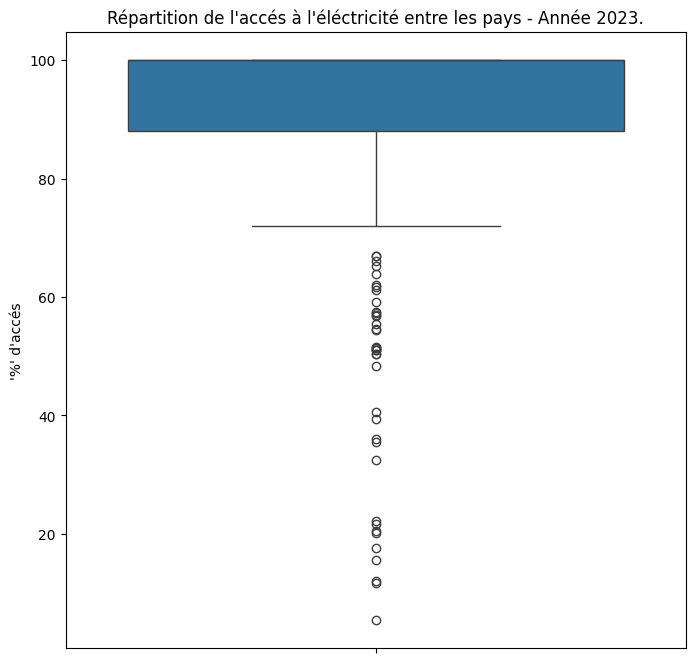

In [22]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='Access_Elec_Pct', data=df_elec)
plt.title("Répartition de l'accés à l'éléctricité entre les pays - Année 2023.")
plt.ylabel("'%' d'accés")

In [23]:
outliers_bas(df_elec, 'Access_Elec_Pct')

Le seuil pour un outlier bas est de :70.00


,Pays,Access_Elec_Pct
16573,Angola,51.1
16584,Burundi,11.6
16586,Bénin,57.0
16587,Burkina Faso,21.7
16602,République centrafricaine,17.6
16611,Congo (Rép. dém.),22.1
16612,Congo,51.3
16624,Djibouti,65.2
16637,Erythrée,54.4
16640,Éthiopie,55.4


Text(0, 0.5, 'Occurences')

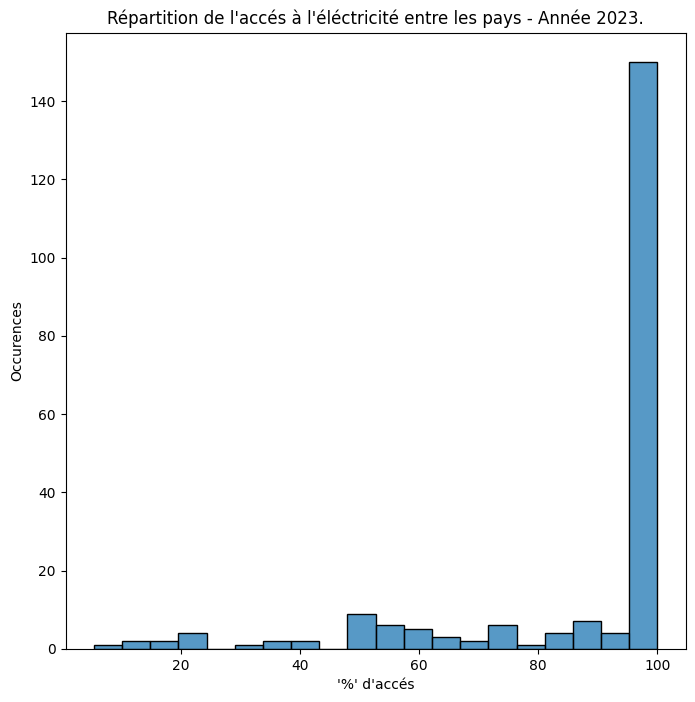

In [24]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_elec, x="Access_Elec_Pct", bins=20)
plt.title("Répartition de l'accés à l'éléctricité entre les pays - Année 2023.")
plt.xlabel("'%' d'accés")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


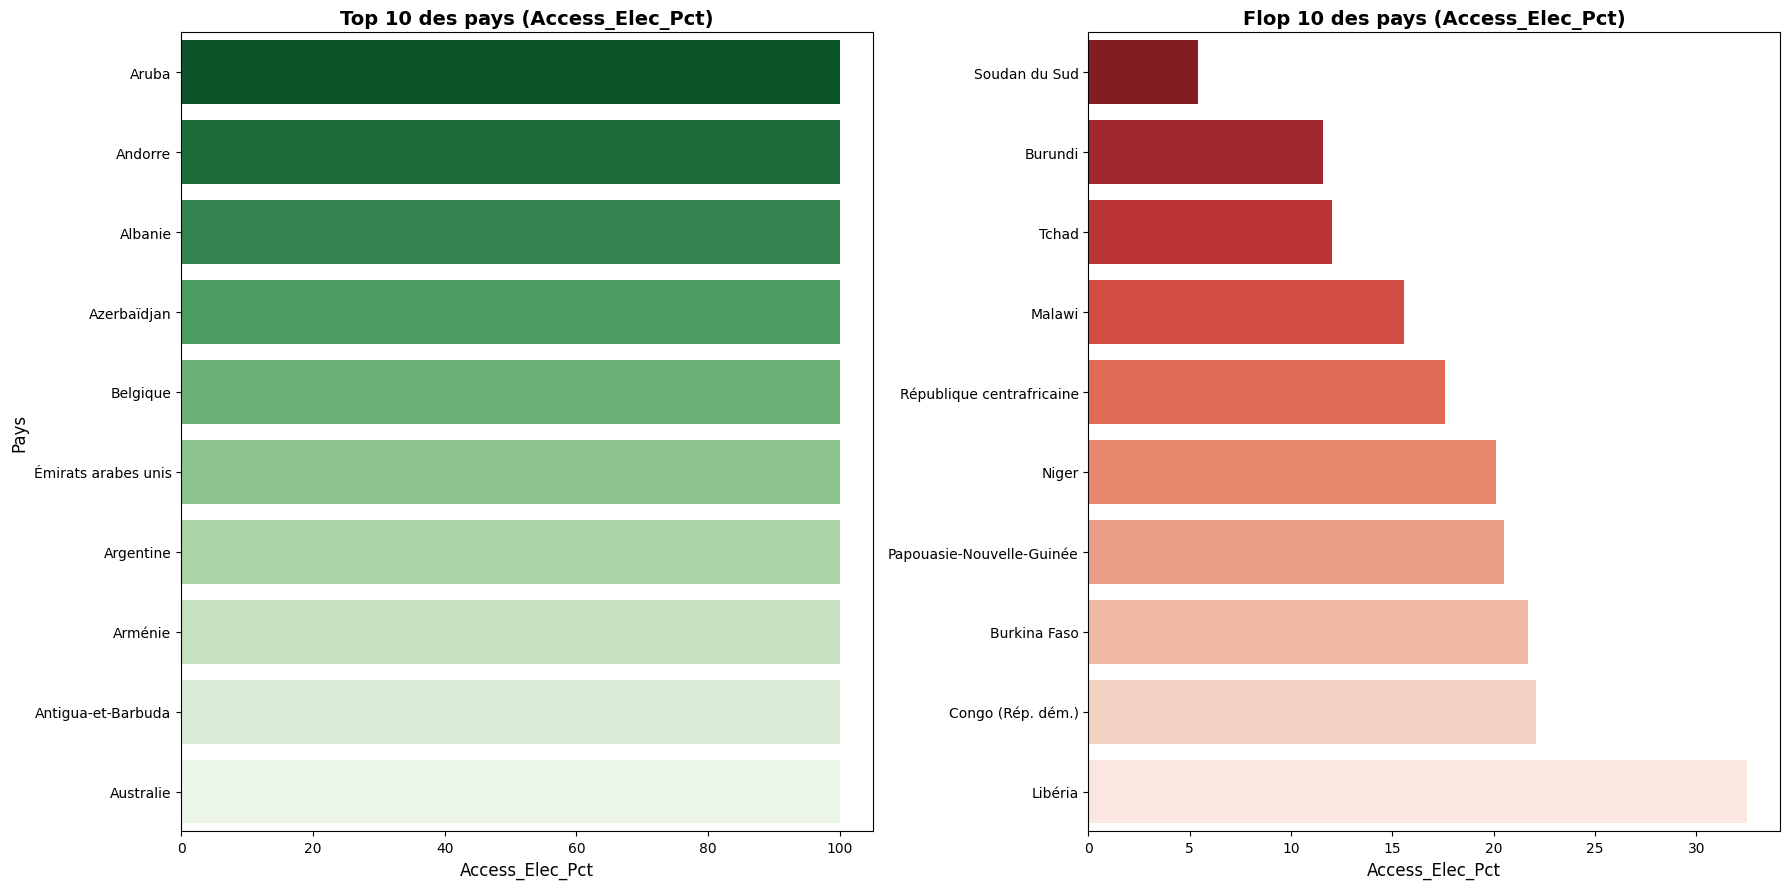

In [25]:
plot_top_flop_10(df_elec, 'Access_Elec_Pct')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_lpi</h2>
</div>

In [26]:
df_lpi.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.492222,NaN,NaN,NaN,2.618182,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.950000,NaN,NaN,NaN,1.900000,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.413333,NaN,NaN,NaN,2.473333,NaN,NaN,NaN,NaN
4,Angola,AGO,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.050000,NaN,NaN,NaN,2.100000,NaN,NaN,NaN,NaN


In [27]:
df_lpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [28]:
df_lpi.duplicated().sum()

np.int64(0)

In [29]:
#3 Il manque beaucoup de valeurs
df_lpi[[str(i) for i in range(2010, 2026)]].isna().sum()

2010     64
2011    266
2012     65
2013    266
2014     59
2015    266
2016     59
2017    266
2018     59
2019    266
2020    266
2021    266
2022     80
2023    266
2024    266
2025    266
dtype: int64

In [30]:
# On va donc faire un forward fill pour prendre la dernière valeur connue et remplir les vides

#1. On prend les colonnes correspondant aux années dans une lsite
col_annees = [col for col in df_lpi.columns if col.isdigit()]
col_annees.sort() # S'assurer que l'ordre va bien de 1960 à 2025

# 2. Appliquer le Forward Fill ligne par ligne (axis=1) sur les colonnes d'années
# Cela va copier la dernière valeur non-nulle vers la droite pour chaque pays
df_lpi[col_annees] = df_lpi[col_annees].ffill(axis=1)

In [31]:
df_lpi[[str(i) for i in range(2010, 2026)]].isna().sum()

2010    55
2011    55
2012    55
2013    55
2014    53
2015    53
2016    51
2017    51
2018    51
2019    51
2020    51
2021    51
2022    49
2023    49
2024    49
2025    49
dtype: int64

In [32]:
# On va melt notre df pour avoir les années dans une colonne, on a déjà la liste des Années
id_cols = ['Country Name', 'Country Code']

df_lpi = pd.melt(
    df_lpi, 
    id_vars=id_cols,
    value_vars=col_annees,
    var_name='Year', 
    value_name='LPI'
)

# On ne garde que l'année 2023 car c'est celle qui est commune à toutes nos données
df_lpi = df_lpi[df_lpi['Year'] == '2023']

# On renomme les colonnes pour uniformiser nos Dataframes
df_lpi = df_lpi.rename(columns={'Country Code' : 'Pays', 'Year' : 'Année'})

# On peut maintenant enlever cette colonne
df_lpi = df_lpi[['Pays', 'LPI', 'Country Name']]
df_lpi

,Pays,LPI,Country Name
16758,ABW,NaN,Aruba
16759,AFE,2.618182,Africa Eastern and Southern
16760,AFG,1.900000,Afghanistan
16761,AFW,2.473333,Africa Western and Central
16762,AGO,2.100000,Angola
...,...,...,...
17019,XKX,NaN,Kosovo
17020,YEM,2.200000,"Yemen, Rep."
17021,ZAF,3.700000,South Africa
17022,ZMB,2.530000,Zambia


In [33]:
# On modifie les noms des Pays
df_lpi['Pays'] = df_lpi['Pays'].replace(dict_code_to_fr)

In [34]:
# On vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_lpi['Pays']) - set(df_corresp['Pays']))
df_lpi.loc[df_lpi['Pays'].isin(verif_Pays), ['Country Name', 'Pays']]

,Country Name,Pays
16759,Africa Eastern and Southern,AFE
16761,Africa Western and Central,AFW
16765,Arab World,ARB
16794,Central Europe and the Baltics,CEB
16796,Channel Islands,CHI
16807,Caribbean small states,CSS
16819,East Asia & Pacific (excluding high income),EAP
16820,Early-demographic dividend,EAR
16821,East Asia & Pacific,EAS
16822,Europe & Central Asia (excluding high income),ECA


In [35]:
# On ne garde que les Pays qui ont la correspondance
df_lpi = df_lpi[~df_lpi['Pays'].isin(verif_Pays)]

# On vérifie
verif_Pays = list(set(df_lpi['Pays']) - set(df_corresp['Pays']))
df_lpi[df_lpi['Pays'].isin(verif_Pays)]

,Pays,LPI,Country Name


In [36]:
df_lpi = df_lpi.drop(columns='Country Name')
df_lpi = df_lpi[~df_lpi['LPI'].isna()]
df_lpi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 16760 to 17023
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pays    169 non-null    object 
 1   LPI     169 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.0+ KB


Text(0, 0.5, 'LPI')

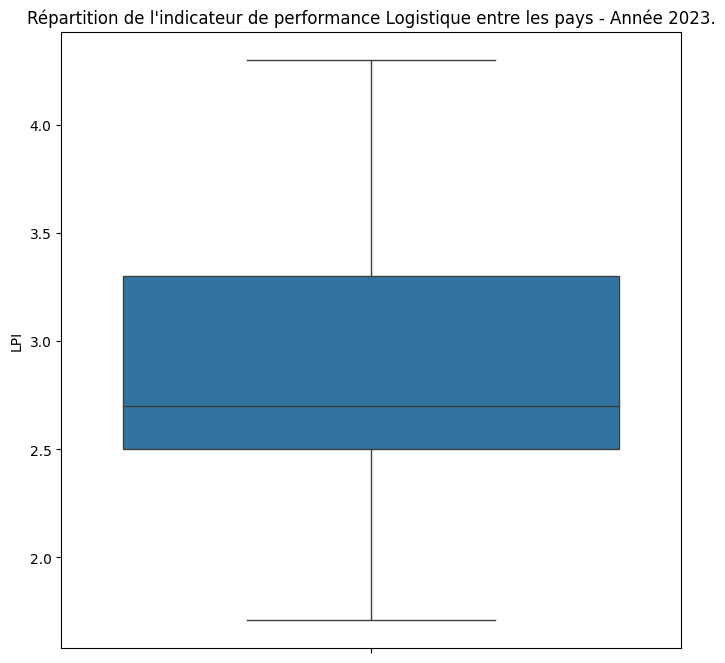

In [37]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='LPI', data=df_lpi)
plt.title("Répartition de l'indicateur de performance Logistique entre les pays - Année 2023.")
plt.ylabel("LPI")

Text(0.5, 0, 'LPI')

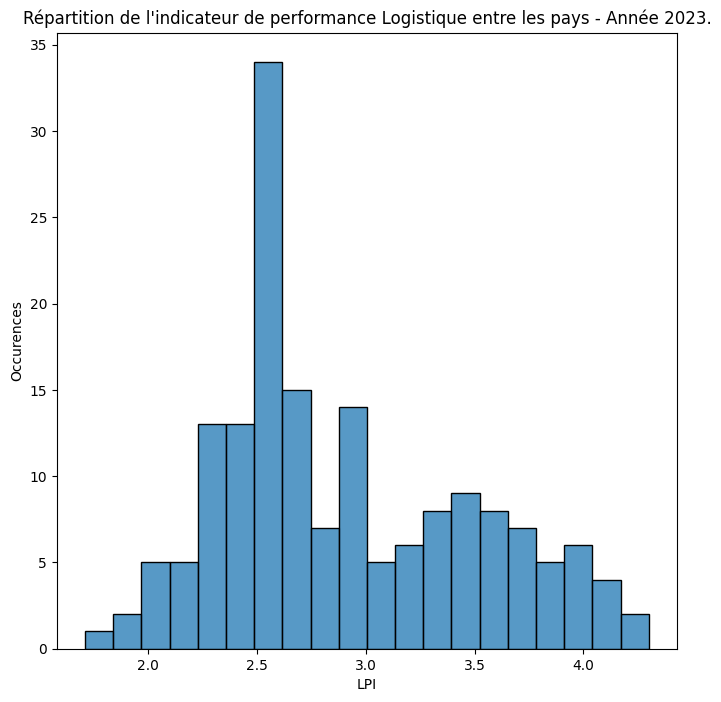

In [38]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_lpi, x="LPI", bins=20)
plt.title("Répartition de l'indicateur de performance Logistique entre les pays - Année 2023.")
plt.ylabel("Occurences")
plt.xlabel('LPI')

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


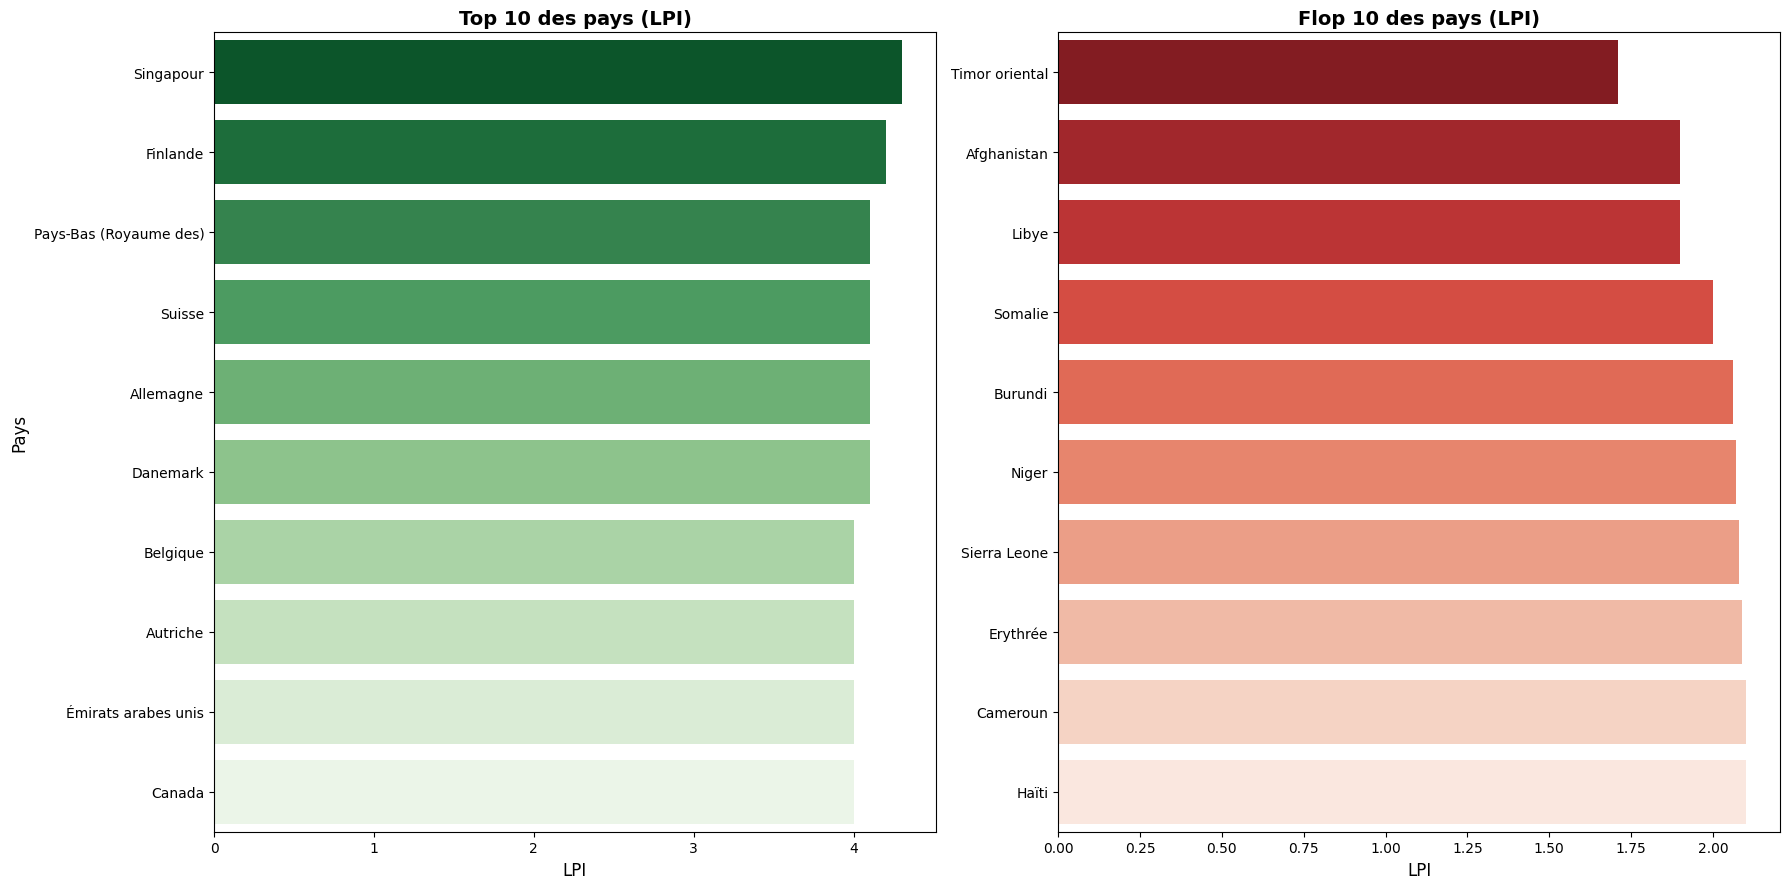

In [39]:
plot_top_flop_10(df_lpi, 'LPI')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_politic</h2>
</div>

In [40]:
df_politic.head()

,Entity,Code,Year,Political polarization score
0,Afghanistan,AFG,1992,2.779
1,Afghanistan,AFG,1993,2.779
2,Afghanistan,AFG,1994,2.779
3,Afghanistan,AFG,1995,2.779
4,Afghanistan,AFG,1996,2.779


In [41]:
df_politic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22868 entries, 0 to 22867
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Entity                        22868 non-null  object 
 1   Code                          21892 non-null  object 
 2   Year                          22868 non-null  int64  
 3   Political polarization score  22868 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 714.8+ KB


In [42]:
df_politic.isnull().sum()

Entity                            0
Code                            976
Year                              0
Political polarization score      0
dtype: int64

In [43]:
df_politic.describe()

,Year,Political polarization score
count,22868.000000,22868.000000
mean,1964.620343,-0.143050
std,35.894710,1.329971
min,1900.000000,-3.813000
25%,1934.000000,-1.110000
50%,1965.000000,-0.071670
75%,1996.000000,0.776250
max,2025.000000,3.940000


In [44]:
# Je veux savoir combien j'ai de pays sur tout mon DF
len(df_politic['Entity'].unique())

197

In [45]:
# On regarde combien on a de Pays pour les années les plus récentes
for i in range(2010, 2026, 1):
    print(f"Nombre de Pays pour l'année {i} : {df_politic.loc[df_politic['Year'] == i, 'Entity'].count()}.")

Nombre de Pays pour l'année 2010 : 193.
Nombre de Pays pour l'année 2011 : 193.
Nombre de Pays pour l'année 2012 : 193.
Nombre de Pays pour l'année 2013 : 193.
Nombre de Pays pour l'année 2014 : 193.
Nombre de Pays pour l'année 2015 : 193.
Nombre de Pays pour l'année 2016 : 193.
Nombre de Pays pour l'année 2017 : 193.
Nombre de Pays pour l'année 2018 : 193.
Nombre de Pays pour l'année 2019 : 193.
Nombre de Pays pour l'année 2020 : 193.
Nombre de Pays pour l'année 2021 : 193.
Nombre de Pays pour l'année 2022 : 193.
Nombre de Pays pour l'année 2023 : 193.
Nombre de Pays pour l'année 2024 : 192.
Nombre de Pays pour l'année 2025 : 189.


In [46]:
# On renomme les colonnes pour uniformiser nos Dataframes
df_politic = df_politic.rename(columns={'Code' : 'Pays', 'Year' : 'Année', 'Political polarization score' : 'Politic_score'})
df_politic = df_politic[df_politic['Année'] == 2023]
df_politic = df_politic[['Pays', 'Entity', 'Politic_score']]
df_politic

,Pays,Entity,Politic_score
31,AFG,Afghanistan,2.485000
157,OWID_AFR,Africa,0.252143
279,NaN,Africa (population-weighted),0.088952
393,ALB,Albania,-0.622000
519,DZA,Algeria,-1.563000
...,...,...,...
22372,NaN,World (population-weighted),0.838582
22425,YEM,Yemen,2.850000
22613,ZMB,Zambia,-0.521000
22739,OWID_ZAN,Zanzibar,-1.348000


In [47]:
# On modifie les noms des Pays
df_politic['Pays'] = df_politic['Pays'].replace(dict_code_to_fr)

In [48]:
df_politic['Pays']

31       Afghanistan
157         OWID_AFR
279              NaN
393          Albanie
519          Algérie
            ...     
22372            NaN
22425          Yémen
22613         Zambie
22739       OWID_ZAN
22865       Zimbabwe
Name: Pays, Length: 193, dtype: object

In [49]:
# On vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_politic['Pays']) - set(df_corresp['Pays']))
df_politic.loc[df_politic['Pays'].isin(verif_Pays), ['Entity', 'Pays']]

,Entity,Pays
157,Africa,OWID_AFR
279,Africa (population-weighted),NaN
1004,Asia,OWID_ASI
1130,Asia (population-weighted),NaN
6958,Europe,OWID_EUR
7084,Europe (population-weighted),NaN
10665,Kosovo,OWID_KOS
14599,North America,OWID_NAM
14725,North America (population-weighted),NaN
15195,Oceania,OWID_OCE


In [50]:
# On ne garde que les Pays qui ont la correspondance
df_politic = df_politic[~df_politic['Pays'].isin(verif_Pays)]

# On vérifie
verif_Pays = list(set(df_politic['Pays']) - set(df_corresp['Pays']))
df_politic[df_politic['Pays'].isin(verif_Pays)]

,Pays,Entity,Politic_score


In [51]:
df_politic = df_politic.drop(columns='Entity')
df_politic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174 entries, 31 to 22865
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pays           174 non-null    object 
 1   Politic_score  174 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.1+ KB


Text(0, 0.5, 'Polarité')

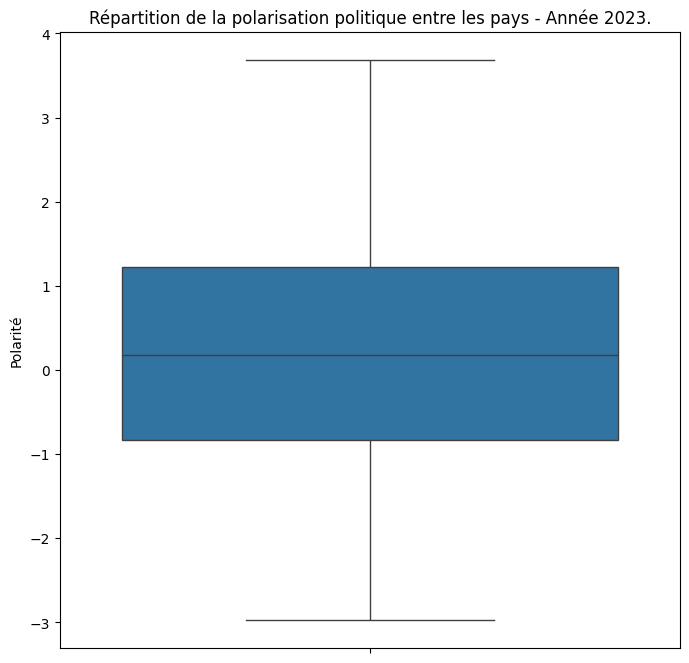

In [52]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='Politic_score', data=df_politic)
plt.title("Répartition de la polarisation politique entre les pays - Année 2023.")
plt.ylabel("Polarité")

Text(0, 0.5, 'Occurences')

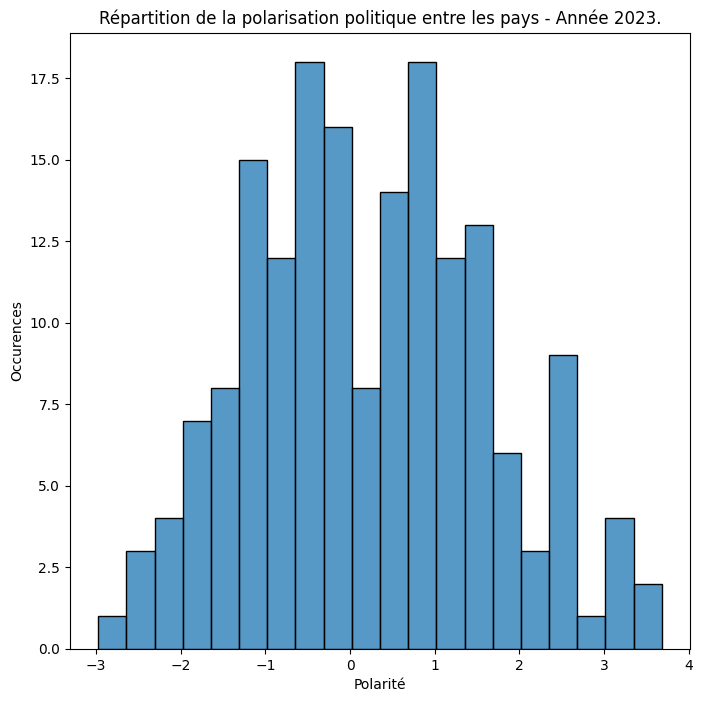

In [53]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_politic, x="Politic_score", bins=20)
plt.title("Répartition de la polarisation politique entre les pays - Année 2023.")
plt.xlabel("Polarité")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


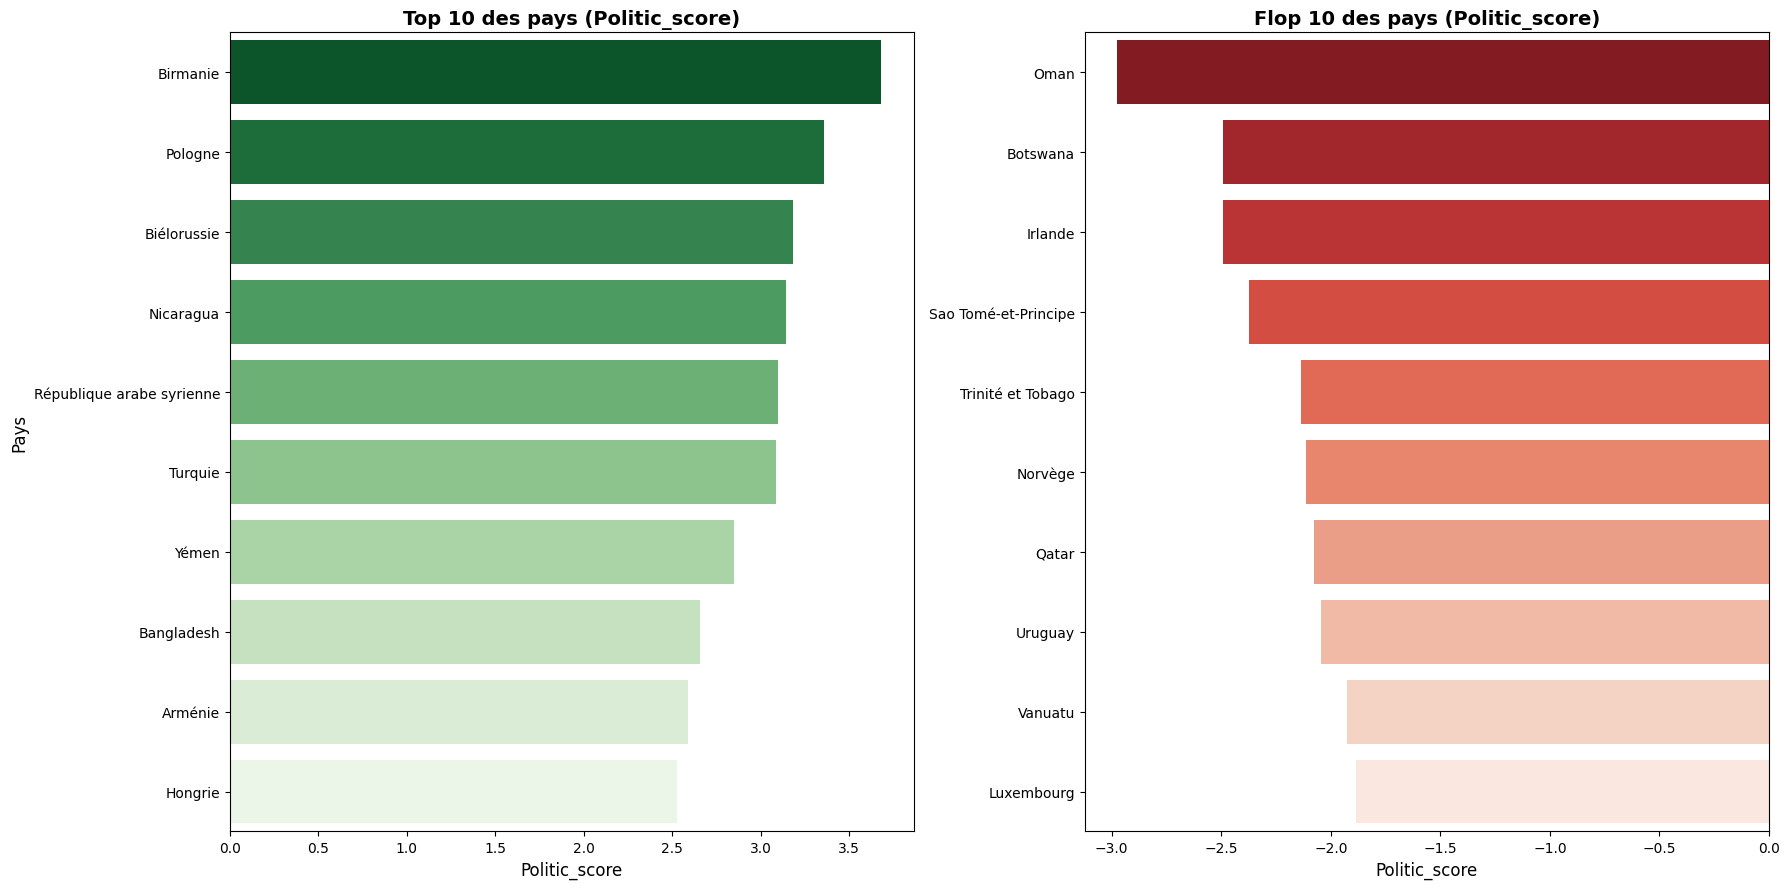

In [54]:
plot_top_flop_10(df_politic, "Politic_score")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_idh</h2>
</div>

In [55]:
df_idh.head()

,Entity,Code,Year,Human Development Index,World region according to OWID
0,Afghanistan,AFG,1990,0.285,Asia
1,Afghanistan,AFG,1991,0.291,Asia
2,Afghanistan,AFG,1992,0.301,Asia
3,Afghanistan,AFG,1993,0.311,Asia
4,Afghanistan,AFG,1994,0.305,Asia


In [56]:
df_idh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6604 entries, 0 to 6603
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Entity                          6604 non-null   object 
 1   Code                            6264 non-null   object 
 2   Year                            6604 non-null   int64  
 3   Human Development Index         6604 non-null   float64
 4   World region according to OWID  5940 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 258.1+ KB


In [57]:
df_idh.describe()

,Year,Human Development Index
count,6604.00000,6604.000000
mean,2007.57344,0.682702
std,9.57497,0.163174
min,1990.00000,0.215000
25%,2000.00000,0.565000
50%,2008.00000,0.705000
75%,2016.00000,0.809000
max,2023.00000,0.972000


In [58]:
df_idh.isnull().sum()

Entity                              0
Code                              340
Year                                0
Human Development Index             0
World region according to OWID    664
dtype: int64

In [59]:
# Je veux savoir combien j'ai de pays sur tout mon DF
len(df_idh['Entity'].unique())

215

In [60]:
# On regarde combien on a de Pays pour les années les plus récentes
for i in range(2010, 2026, 1):
    print(f"Nombre de Pays pour l'année {i} : {df_idh.loc[df_idh['Year'] == i, 'Entity'].count()}.")

Nombre de Pays pour l'année 2010 : 213.
Nombre de Pays pour l'année 2011 : 214.
Nombre de Pays pour l'année 2012 : 214.
Nombre de Pays pour l'année 2013 : 214.
Nombre de Pays pour l'année 2014 : 214.
Nombre de Pays pour l'année 2015 : 214.
Nombre de Pays pour l'année 2016 : 214.
Nombre de Pays pour l'année 2017 : 214.
Nombre de Pays pour l'année 2018 : 214.
Nombre de Pays pour l'année 2019 : 214.
Nombre de Pays pour l'année 2020 : 214.
Nombre de Pays pour l'année 2021 : 214.
Nombre de Pays pour l'année 2022 : 214.
Nombre de Pays pour l'année 2023 : 215.
Nombre de Pays pour l'année 2024 : 0.
Nombre de Pays pour l'année 2025 : 0.


In [61]:
df_idh.head()

,Entity,Code,Year,Human Development Index,World region according to OWID
0,Afghanistan,AFG,1990,0.285,Asia
1,Afghanistan,AFG,1991,0.291,Asia
2,Afghanistan,AFG,1992,0.301,Asia
3,Afghanistan,AFG,1993,0.311,Asia
4,Afghanistan,AFG,1994,0.305,Asia


In [62]:
# On renomme les colonnes pour uniformiser nos Dataframes
df_idh = df_idh.rename(columns={'Code' : 'Pays', 'Year' : 'Année', 'Human Development Index' : 'IDH'})
df_idh = df_idh[df_idh['Année'] == 2023]
df_idh = df_idh[['Pays', 'Entity', 'IDH']]
df_idh

,Pays,Entity,IDH
33,AFG,Afghanistan,0.496000
57,OWID_AFR,Africa,0.576059
91,ALB,Albania,0.810000
125,DZA,Algeria,0.763000
149,AND,Andorra,0.913000
...,...,...,...
6467,VNM,Vietnam,0.766000
6501,OWID_WRL,World,0.756000
6535,YEM,Yemen,0.470000
6569,ZMB,Zambia,0.595000


In [63]:
# On modifie les noms des Pays
df_idh['Pays'] = df_idh['Pays'].replace(dict_code_to_fr)

In [64]:
df_idh['Pays']

33      Afghanistan
57         OWID_AFR
91          Albanie
125         Algérie
149         Andorre
           ...     
6467       Viet Nam
6501       OWID_WRL
6535          Yémen
6569         Zambie
6603       Zimbabwe
Name: Pays, Length: 215, dtype: object

In [65]:
# On vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_idh['Pays']) - set(df_corresp['Pays']))
df_idh.loc[df_idh['Pays'].isin(verif_Pays), ['Entity', 'Pays']]

,Entity,Pays
57,Africa,OWID_AFR
225,Arab States (UNDP),NaN
317,Asia,OWID_ASI
1672,East Asia and the Pacific (UNDP),NaN
1962,Europe,OWID_EUR
1996,Europe and Central Asia (UNDP),NaN
2030,European Union (27),OWID_EU27
2537,High human development (UNDP),NaN
2571,High-income countries,OWID_HIC
3270,Latin America and the Caribbean (UNDP),NaN


In [66]:
# On ne garde que les Pays qui ont la correspondance
df_idh = df_idh[~df_idh['Pays'].isin(verif_Pays)]

# On vérifie
verif_Pays = list(set(df_idh['Pays']) - set(df_corresp['Pays']))
df_idh[df_idh['Pays'].isin(verif_Pays)]

,Pays,Entity,IDH


In [67]:
df_idh = df_idh.drop(columns='Entity')
df_idh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 33 to 6603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pays    193 non-null    object 
 1   IDH     193 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.5+ KB


Text(0, 0.5, 'IDH')

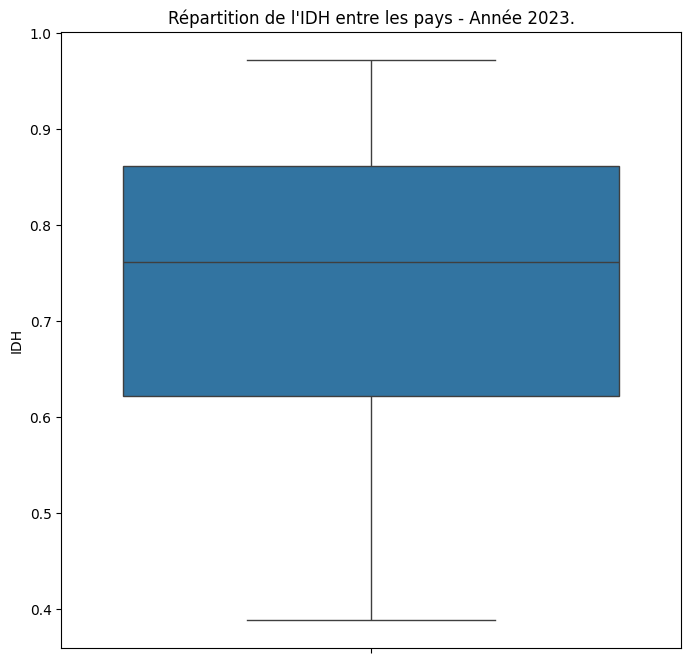

In [68]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='IDH', data=df_idh)
plt.title("Répartition de l'IDH entre les pays - Année 2023.")
plt.ylabel("IDH")

Text(0, 0.5, 'Occurences')

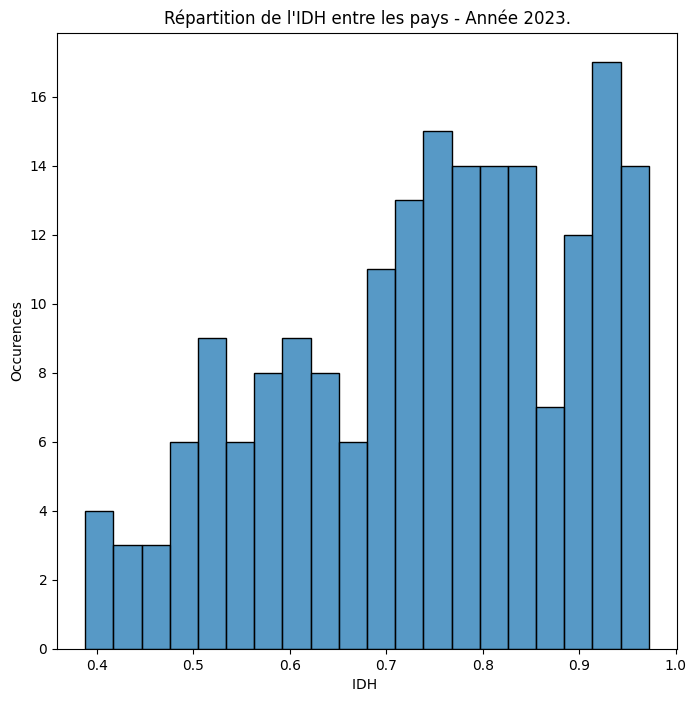

In [69]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_idh, x="IDH", bins=20)
plt.title("Répartition de l'IDH entre les pays - Année 2023.")
plt.xlabel("IDH ")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


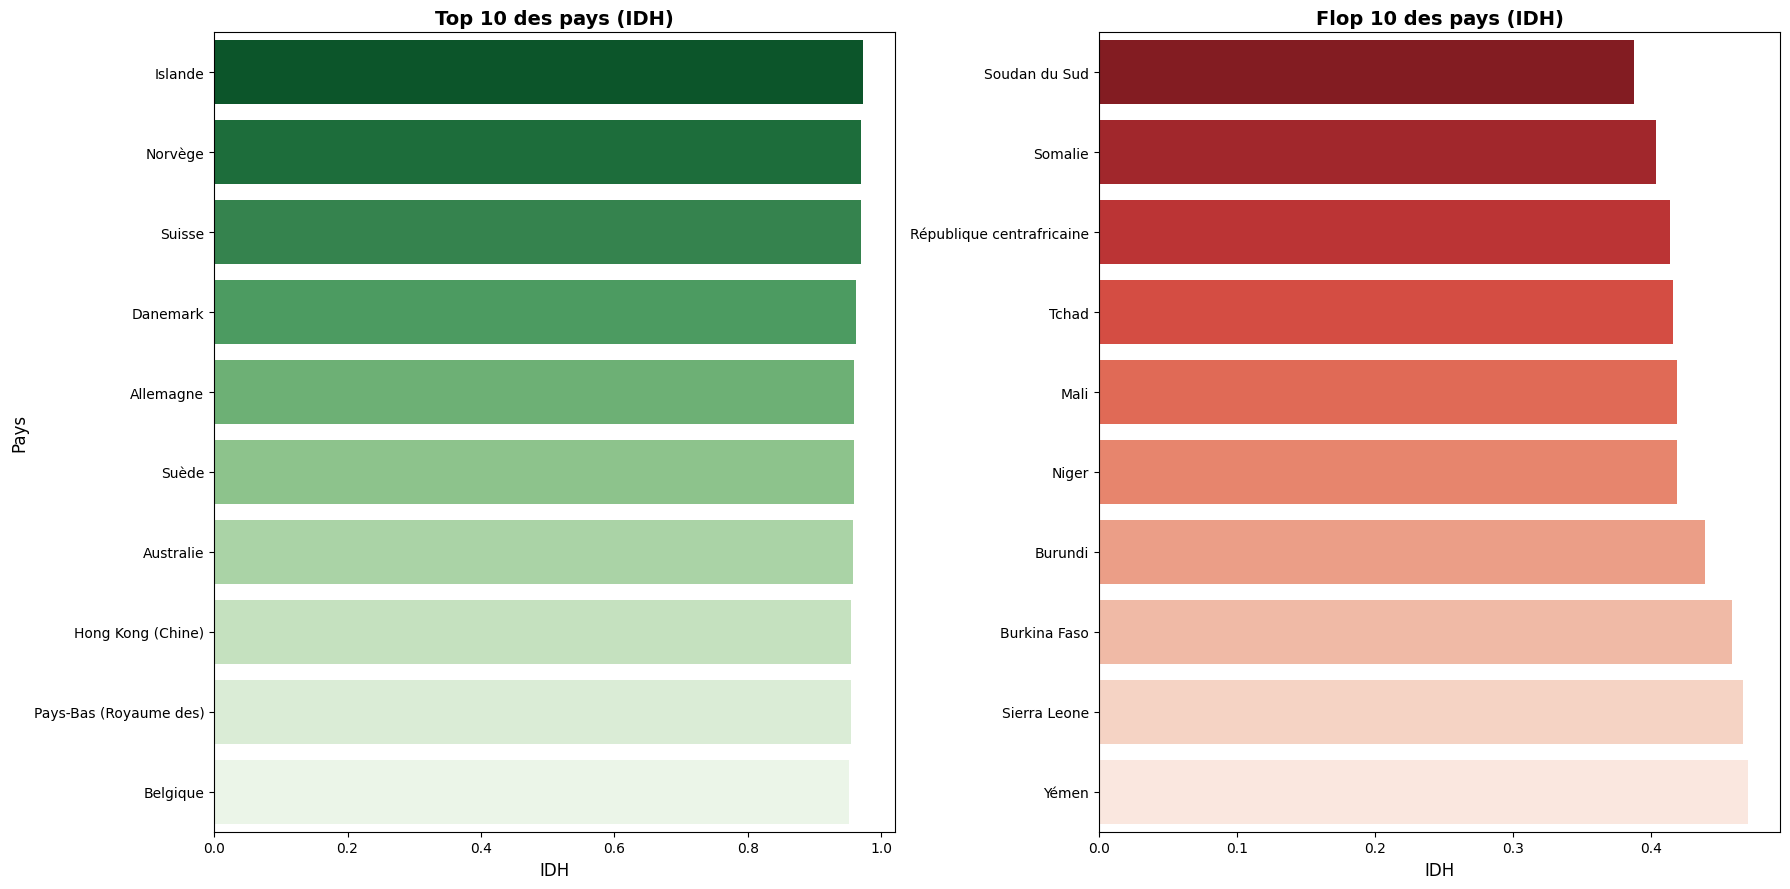

In [70]:
plot_top_flop_10(df_idh, 'IDH')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_cout_viande_saine</h2>
</div>

In [71]:
df_alim_saine.head()
#J'ai deux infos ici que je vais traiter dans 2 dfs différents. D'abord, le cout d'une alimentation saine par pays.

,Domaine,Zone,Élément,Produit,Année,Édition,Unité,Valeur
0,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,"Cost of animal source foods, LCU per person pe...",2021,Juillet 2025 (rapport SOFI),UML/personne/jour,7.51
1,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,"Cost of animal source foods, PPP dollar per pe...",2021,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,1
2,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2017,Juillet 2025 (rapport SOFI),millions de No,35
3,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2018,Juillet 2025 (rapport SOFI),millions de No,35.3
4,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2019,Juillet 2025 (rapport SOFI),millions de No,35.9


In [72]:
df_cout_viande_saine = df_alim_saine[df_alim_saine['Produit'] == 'Cost of animal source foods, PPP dollar per person per day']
df_cout_viande_saine.head()

,Domaine,Zone,Élément,Produit,Année,Édition,Unité,Valeur
1,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,"Cost of animal source foods, PPP dollar per pe...",2021,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,1
11,Coût et abordabilité d’une alimentation saine\...,Albanie,Valeur,"Cost of animal source foods, PPP dollar per pe...",2021,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,1.13
21,Coût et abordabilité d’une alimentation saine\...,Algérie,Valeur,"Cost of animal source foods, PPP dollar per pe...",2021,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,1.36
31,Coût et abordabilité d’une alimentation saine\...,Allemagne,Valeur,"Cost of animal source foods, PPP dollar per pe...",2021,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,0.66
41,Coût et abordabilité d’une alimentation saine\...,Angola,Valeur,"Cost of animal source foods, PPP dollar per pe...",2021,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,1.15


In [73]:
df_cout_viande_saine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 1 to 1741
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Domaine  175 non-null    object
 1   Zone     175 non-null    object
 2   Élément  175 non-null    object
 3   Produit  175 non-null    object
 4   Année    175 non-null    int64 
 5   Édition  175 non-null    object
 6   Unité    175 non-null    object
 7   Valeur   166 non-null    object
dtypes: int64(1), object(7)
memory usage: 12.3+ KB


In [74]:
#Ma colonne valeur est type objet, je vais al passer en numérique et voir si je ne eprs pas trop d'information.

df_cout_viande_saine['Valeur'] = pd.to_numeric(df_alim_saine['Valeur'], errors='coerce')

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\3048831957.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cout_viande_saine['Valeur'] = pd.to_numeric(df_alim_saine['Valeur'], errors='coerce')


In [75]:
df_cout_viande_saine.isnull().sum()

Domaine    0
Zone       0
Élément    0
Produit    0
Année      0
Édition    0
Unité      0
Valeur     9
dtype: int64

9 c'est la même différence qu'avant la transformation du type de la colonne. On va regarder quels pays sont concernés par les valeurs nulles.

In [76]:
df_cout_viande_saine.loc[df_cout_viande_saine['Valeur'].isnull(), 'Zone']

71                               Argentine
131                                Bahamas
701                                 Guyana
711                                  Haïti
751                Îles Turques-et-Caïques
791         Iran (République islamique d')
1121                               Myanmar
1531    Sint Maarten (partie néerlandaise)
1741                              Zimbabwe
Name: Zone, dtype: object

Malheureusement, ce sont des pays à instabilité économique ou politique forte. Je vais devoir les supprimer de l'étude.

In [77]:
df_cout_viande_saine.describe()

,Année,Valeur
count,175.0,166.000000
mean,2021.0,1.001807
std,0.0,0.282650
min,2021.0,0.430000
25%,2021.0,0.782500
50%,2021.0,0.995000
75%,2021.0,1.190000
max,2021.0,1.820000


In [78]:
df_cout_viande_saine = df_cout_viande_saine[['Zone', 'Valeur']]
df_cout_viande_saine = df_cout_viande_saine.rename(columns={'Valeur' : 'cout_viande_saine', 'Zone' : 'Pays'})
df_cout_viande_saine = df_cout_viande_saine[~df_cout_viande_saine['cout_viande_saine'].isna()]
df_cout_viande_saine

,Pays,cout_viande_saine
1,Afrique du Sud,1.00
11,Albanie,1.13
21,Algérie,1.36
31,Allemagne,0.66
41,Angola,1.15
...,...,...
1691,Tunisie,1.15
1701,Turquie,1.13
1711,Uruguay,0.87
1721,Viet Nam,1.30


In [79]:
# Comme la colonne pays est déjà en fr, on vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_cout_viande_saine['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Palestine',
 'Chine - RAS de Hong-Kong',
 'Saint-Kitts-et-Nevis',
 'Chine, Taiwan Province de']

In [80]:
df_cout_viande_saine.loc[df_cout_viande_saine['Pays'] == 'Palestine', 'Pays'] = 'Territoires palestiniens'
df_cout_viande_saine.loc[df_cout_viande_saine['Pays'] == 'Chine, Taiwan Province de', 'Pays'] = 'Taïwan'
df_cout_viande_saine.loc[df_cout_viande_saine['Pays'] == 'Saint-Kitts-et-Nevis', 'Pays'] = 'Saint-Christophe-et-Niévès'
verif_Pays = list(set(df_cout_viande_saine['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Chine - RAS de Hong-Kong']

In [81]:
df_cout_viande_saine = df_cout_viande_saine.groupby('Pays')['cout_viande_saine'].sum().reset_index()

Text(0, 0.5, 'Coût en $')

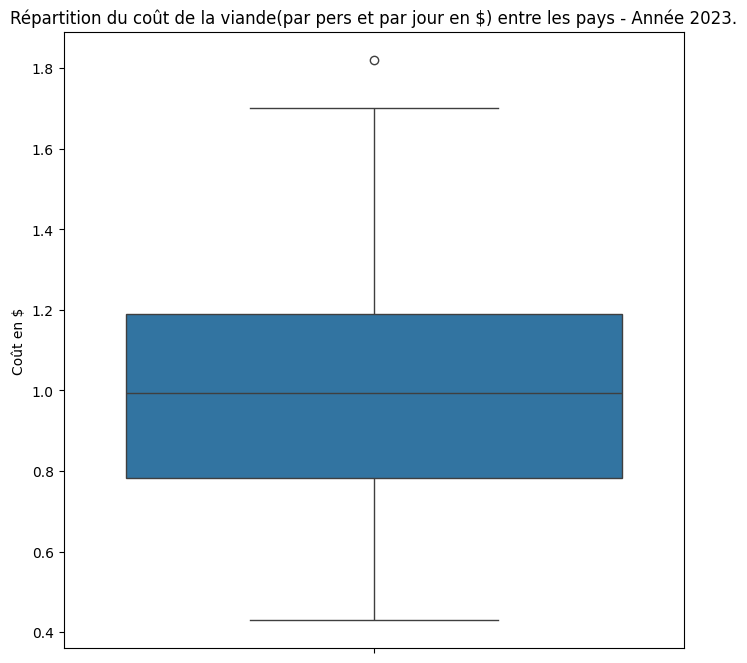

In [82]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='cout_viande_saine', data=df_cout_viande_saine)
plt.title("Répartition du coût de la viande(par pers et par jour en $) entre les pays - Année 2023.")
plt.ylabel("Coût en $")

In [83]:
outliers_hauts(df_cout_viande_saine, 'cout_viande_saine')

Le seuil pour un outlier haut est de :1.80


,Pays,cout_viande_saine
121,République arabe syrienne,1.82


Text(0, 0.5, 'Occurences')

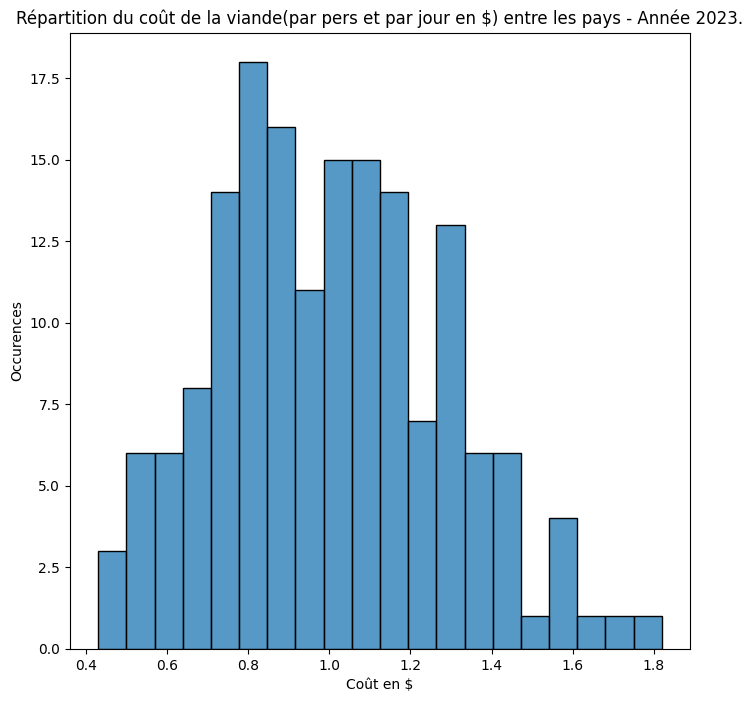

In [84]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_cout_viande_saine, x="cout_viande_saine", bins=20)
plt.title("Répartition du coût de la viande(par pers et par jour en $) entre les pays - Année 2023.")
plt.xlabel("Coût en $")
plt.ylabel("Occurences")

In [85]:
df_cout_viande_saine.sort_values(by='cout_viande_saine', ascending=False).head()

,Pays,cout_viande_saine
121,République arabe syrienne,1.82
101,Niger,1.70
159,Égypte,1.65
39,Congo (Rép. dém.),1.61
29,Cameroun,1.60


In [86]:
df_cout_viande_saine[df_cout_viande_saine['Pays'].isin(['France', 'Canada', 'Japon'])]

,Pays,cout_viande_saine
30,Canada,0.95
52,France,0.56
73,Japon,1.02


# Je n'ai pas de données suffisament récentes, je ne vais donc pas garder ces données pour l'analyse.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_pop_sans_alim_saine</h2>
</div>

In [87]:
df_pop_sans_alim_saine = df_alim_saine[df_alim_saine['Produit'] == 'Number of people unable to afford a healthy diet (NUA), million']

In [88]:
df_pop_sans_alim_saine

,Domaine,Zone,Élément,Produit,Année,Édition,Unité,Valeur
2,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2017,Juillet 2025 (rapport SOFI),millions de No,35
3,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2018,Juillet 2025 (rapport SOFI),millions de No,35.3
4,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2019,Juillet 2025 (rapport SOFI),millions de No,35.9
5,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2020,Juillet 2025 (rapport SOFI),millions de No,37.4
6,Coût et abordabilité d’une alimentation saine\...,Afrique du Sud,Valeur,Number of people unable to afford a healthy di...,2021,Juillet 2025 (rapport SOFI),millions de No,37.6
...,...,...,...,...,...,...,...,...
1745,Coût et abordabilité d’une alimentation saine\...,Zimbabwe,Valeur,Number of people unable to afford a healthy di...,2020,Juillet 2025 (rapport SOFI),millions de No,NaN
1746,Coût et abordabilité d’une alimentation saine\...,Zimbabwe,Valeur,Number of people unable to afford a healthy di...,2021,Juillet 2025 (rapport SOFI),millions de No,NaN
1747,Coût et abordabilité d’une alimentation saine\...,Zimbabwe,Valeur,Number of people unable to afford a healthy di...,2022,Juillet 2025 (rapport SOFI),millions de No,NaN
1748,Coût et abordabilité d’une alimentation saine\...,Zimbabwe,Valeur,Number of people unable to afford a healthy di...,2023,Juillet 2025 (rapport SOFI),millions de No,NaN


In [89]:
df_pop_sans_alim_saine = df_pop_sans_alim_saine[['Zone', 'Année', 'Valeur']]
df_pop_sans_alim_saine = df_pop_sans_alim_saine.rename(columns={'Valeur' : 'pop_sans_alim_saine', 'Zone' : 'Pays'})
df_pop_sans_alim_saine['pop_sans_alim_saine'] = pd.to_numeric(
    df_pop_sans_alim_saine['pop_sans_alim_saine'], 
    errors='coerce'
)
df_pop_sans_alim_saine

,Pays,Année,pop_sans_alim_saine
2,Afrique du Sud,2017,35.0
3,Afrique du Sud,2018,35.3
4,Afrique du Sud,2019,35.9
5,Afrique du Sud,2020,37.4
6,Afrique du Sud,2021,37.6
...,...,...,...
1745,Zimbabwe,2020,NaN
1746,Zimbabwe,2021,NaN
1747,Zimbabwe,2022,NaN
1748,Zimbabwe,2023,NaN


In [90]:
# le chiffre est en millions de personnes, il faut le multiplier par 10^^6
df_pop_sans_alim_saine.loc[:,'pop_sans_alim_saine'] *= 1_000_000

In [91]:
# On regarde combien on a de Pays pour les années les plus récentes
for i in range(2010, 2026, 1):
    print(f"Nombre de Pays pour l'année {i} : {df_pop_sans_alim_saine.loc[df_pop_sans_alim_saine['Année'] == i, 'Pays'].count()}.")

Nombre de Pays pour l'année 2010 : 0.
Nombre de Pays pour l'année 2011 : 0.
Nombre de Pays pour l'année 2012 : 0.
Nombre de Pays pour l'année 2013 : 0.
Nombre de Pays pour l'année 2014 : 0.
Nombre de Pays pour l'année 2015 : 0.
Nombre de Pays pour l'année 2016 : 0.
Nombre de Pays pour l'année 2017 : 175.
Nombre de Pays pour l'année 2018 : 175.
Nombre de Pays pour l'année 2019 : 175.
Nombre de Pays pour l'année 2020 : 175.
Nombre de Pays pour l'année 2021 : 175.
Nombre de Pays pour l'année 2022 : 175.
Nombre de Pays pour l'année 2023 : 175.
Nombre de Pays pour l'année 2024 : 175.
Nombre de Pays pour l'année 2025 : 0.


In [92]:
df_pop_sans_alim_saine = df_pop_sans_alim_saine[df_pop_sans_alim_saine['Année'] == 2023]

In [93]:
df_pop_sans_alim_saine.isnull().sum()

Pays                    0
Année                   0
pop_sans_alim_saine    34
dtype: int64

In [94]:
df_pop_sans_alim_saine.loc[df_pop_sans_alim_saine['pop_sans_alim_saine'].isnull(), 'Pays']

58                      Antigua-et-Barbuda
68                         Arabie Saoudite
78                               Argentine
98                                   Aruba
138                                Bahamas
148                                Bahreïn
208                               Bermudes
218                                Bhoutan
268                                 Brunei
318                               Cambodge
358               Chine - RAS de Hong-Kong
388                                 Chypre
458                                Curaçao
488                              Dominique
658                                Grenade
688                     Guinée-Équatoriale
748                           Îles Caïmans
758                Îles Turques-et-Caïques
768              Îles Vierges britanniques
828                                Islande
918                                 Koweït
978                             Luxembourg
1028                              Maldives
1048       

# Il me manque beaucoup de pays importants, je vais exclure ces données de mon analyse.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_dist</h2>
</div>

In [95]:
df_dist.head()

,iso_o,iso_d,dist
0,FRA,ABW,"7685,884"
1,FRA,AFG,"5590,381"
2,FRA,AGO,"6510,322"
3,FRA,AIA,"6710,57"
4,FRA,ALB,"1603,534"


In [96]:
df_dist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   iso_o   224 non-null    object
 1   iso_d   224 non-null    object
 2   dist    224 non-null    object
dtypes: object(3)
memory usage: 5.4+ KB


Le df a l'air plein, pas de valeurs nulles. En revanche, il faut renommer les colonnes et modifier le type de la colonne dist

In [97]:
df_dist = df_dist[['iso_d', 'dist']]
df_dist = df_dist.rename(columns={'iso_d' : 'Pays'})
df_dist['dist'] = df_dist['dist'].str.replace(',', '.').astype(float)
df_dist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pays    224 non-null    object 
 1   dist    224 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.6+ KB


In [98]:
# On modifie les noms des Pays
df_dist['Pays'] = df_dist['Pays'].replace(dict_code_to_fr)

In [99]:
# On vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_dist['Pays']) - set(df_corresp['Pays']))
verif_Pays

['GLP',
 'TKL',
 'PYF',
 'NCL',
 'SPM',
 'AIA',
 'SHN',
 'NFK',
 'ANT',
 'GUF',
 'MTQ',
 'MSR',
 'PAL',
 'NIU',
 'TMP',
 'PCN',
 'COK',
 'REU',
 'CXR',
 'WLF',
 'CCK',
 'YUG',
 'ESH',
 'FLK']

Après vérification, ce sont des territoires rattachés à d'autres pays (ex: MTQ =  Martinique qui est la France)

In [100]:
# On ne garde que les Pays qui ont la correspondance
df_dist = df_dist[~df_dist['Pays'].isin(verif_Pays)]

In [101]:
df_dist.drop( df_dist[ df_dist['Pays'] == 'France' ].index, inplace=True)

Text(0, 0.5, 'Distance')

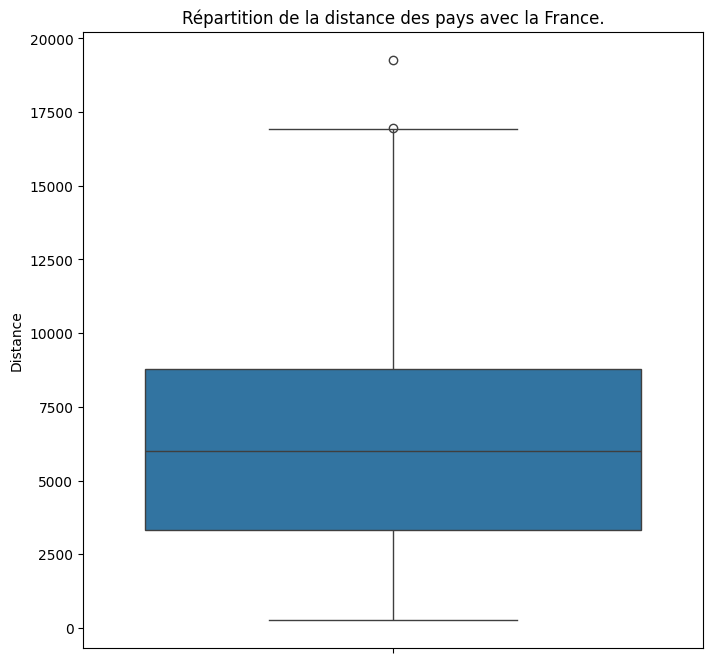

In [102]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='dist', data=df_dist)
plt.title("Répartition de la distance des pays avec la France.")
plt.ylabel("Distance")

In [103]:
outliers_hauts(df_dist, 'dist')

Le seuil pour un outlier haut est de :16943.65


,Pays,dist
11,Australie,16975.46
151,Nouvelle-Zélande,19263.88


Text(0, 0.5, 'Occurences')

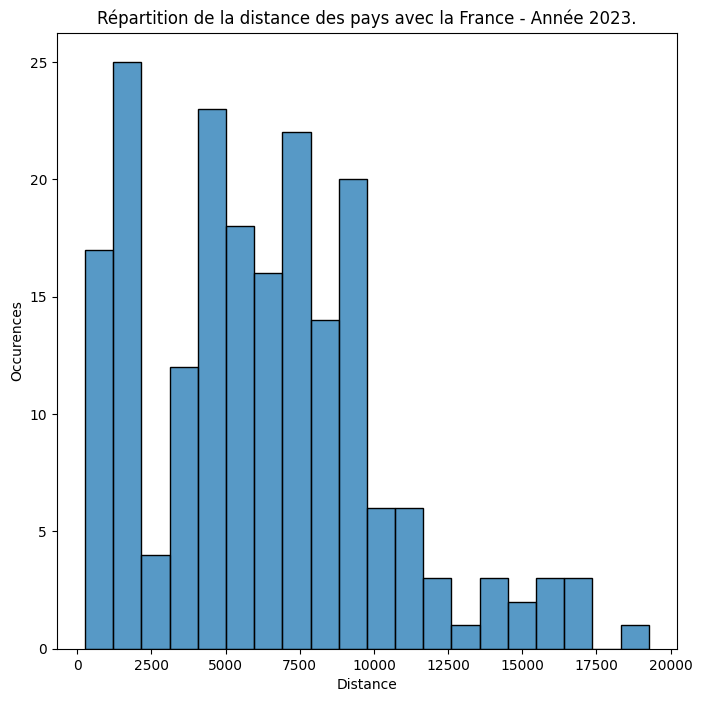

In [104]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_dist, x="dist", bins=20)
plt.title("Répartition de la distance des pays avec la France - Année 2023.")
plt.xlabel("Distance")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\3236219699.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\3236219699.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


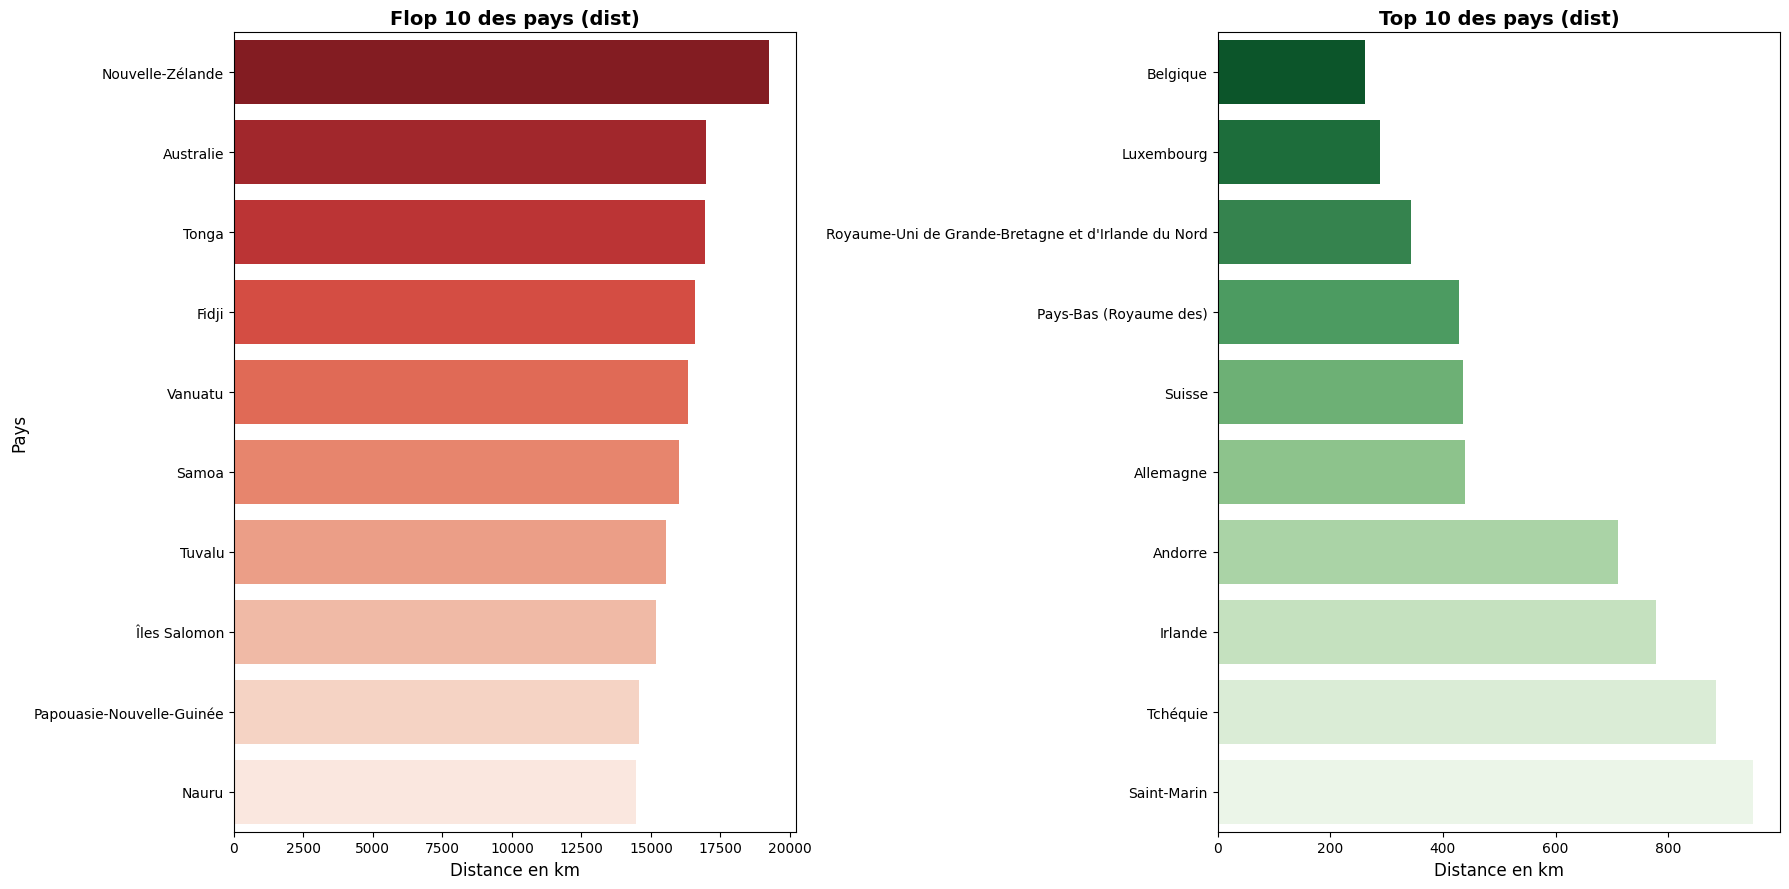

In [105]:
# Extraction du Top 10 (tri décroissant)
top_10 = df_dist.sort_values(by='dist', ascending=False).head(10)

# Extraction du Flop 10 (tri croissant)
flop_10 = df_dist.sort_values(by='dist', ascending=True).head(10)

# 2. Création de la figure (2 graphiques côte à côte)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 9))

# --- Graphique 1 : TOP 10 ---
sns.barplot(
    data=top_10, 
    x='dist', 
    y='Pays', 
    ax=axes[0], 
    palette="Reds_r" # Dégradé de vert (du plus grand au plus petit)
)
axes[0].set_title(f"Flop 10 des pays ({'dist'})", fontsize=14, fontweight='bold')
axes[0].set_xlabel('Distance en km', fontsize=12)
axes[0].set_ylabel("Pays", fontsize=12)

# --- Graphique 2 : FLOP 10 ---
sns.barplot(
    data=flop_10, 
    x='dist', 
    y='Pays', 
    ax=axes[1], 
    palette="Greens_r" # Dégradé de rouge/orangé
)
axes[1].set_title(f"Top 10 des pays ({'dist'})", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Distance en km', fontsize=12)
axes[1].set_ylabel("") # On enlève le label Y pour ne pas surcharger le milieu

# Ajustement automatique des espaces
plt.tight_layout()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_population</h2>
</div>

In [106]:
df_population.head()

,Domaine,Zone,Élément,Produit,Année,Unité,Valeur
0,Séries temporelles annuelles,Afghanistan,Population totale,Population-Estimations,1950,1000 No,7776.176
1,Séries temporelles annuelles,Afghanistan,Population totale,Population-Estimations,1951,1000 No,7879.339
2,Séries temporelles annuelles,Afghanistan,Population totale,Population-Estimations,1952,1000 No,7987.783
3,Séries temporelles annuelles,Afghanistan,Population totale,Population-Estimations,1953,1000 No,8096.698
4,Séries temporelles annuelles,Afghanistan,Population totale,Population-Estimations,1954,1000 No,8207.950


In [107]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15939 entries, 0 to 15938
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domaine  15939 non-null  object 
 1   Zone     15939 non-null  object 
 2   Élément  15939 non-null  object 
 3   Produit  15939 non-null  object 
 4   Année    15939 non-null  int64  
 5   Unité    15939 non-null  object 
 6   Valeur   15939 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 871.8+ KB


le fichier a l'air complet, c'est parfait.

In [108]:
#Comme d'habitude, on renomme les colonnes intéressantes et on supprime celles inutiles. Ensuite on filtre sur 2023.
df_population = df_population.rename(columns={'Valeur':'population', 'Zone' : 'Pays'})
df_population = df_population[df_population['Année'] == 2023]
df_population = df_population[['Pays', 'population']]

In [109]:
#La population est en milliers d'habitants, il faut la multiplier par 1000
df_population.loc[:, 'population'] *= 1000

In [110]:
df_population

,Pays,population
73,Afghanistan,41454761.0
147,Afrique du Sud,63212384.0
221,Albanie,2811655.0
295,Algérie,46164219.0
369,Allemagne,84548231.0
...,...,...
15642,Venezuela (République bolivarienne du),28300854.0
15716,Viet Nam,100352192.0
15790,Yémen,39390799.0
15864,Zambie,20723965.0


In [111]:
# Comme la colonne pays est déjà en fr, on vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_population['Pays']) - set(df_corresp['Pays']))
verif_Pays

['République populaire démocratique de Corée',
 'Cabo Verde',
 'Polynésie française',
 'République démocratique du Congo',
 'Saint-Barthélemy',
 'Bonaire, Saint-Eustache et Saba',
 'Sint Maarten (partie néerlandaise)',
 'El Salvador',
 'Nioué',
 'Érythrée',
 'Martinique',
 'Chine, continentale',
 'Guinée équatoriale',
 'Venezuela (République bolivarienne du)',
 'Montserrat',
 'Bolivie (État plurinational de)',
 'Îles Vierges américaines',
 'Chine - RAS de Macao',
 'Tokélaou',
 'Sahara occidental',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago',
 'Chine, Taiwan Province de',
 'Mayotte',
 "Iran (République islamique d')",
 'Nouvelle-Calédonie',
 'Arabie saoudite',
 'Îles Caïmanes',
 'Chine - RAS de Hong-Kong',
 'Anguilla',
 'Réunion',
 'Bélarus',
 'Îles Falkland (Malvinas)',
 'Timor-Leste',
 'Guyane française',
 'Palestine',
 'Ascension, Sainte-Hélène et Tristan da Cunha',
 'Îles Wallis-et-Futuna',
 'Micronésie (États fédérés de)',
 'Türkiye',
 'Îles Cook',
 'Myanmar',
 'Saint-Vincent-et-

In [112]:
# On uniformise 
df_population.loc[df_population['Pays'] == 'Îles Caïmanes', 'Pays'] = 'Îles Caïmans'
df_population.loc[df_population['Pays'] == 'Bolivie (État plurinational de)', 'Pays'] = 'Bolivie'
df_population.loc[df_population['Pays'] == 'Myanmar', 'Pays'] = 'Birmanie'
df_population.loc[df_population['Pays'] == 'Guinée équatoriale', 'Pays'] = 'Guinée-Équatoriale'
df_population.loc[df_population['Pays'] == 'Cabo Verde', 'Pays'] = 'Cap Vert'
df_population.loc[df_population['Pays'] == 'Bélarus', 'Pays'] = 'Biélorussie'
df_population.loc[df_population['Pays'] == 'Érythrée', 'Pays'] = 'Erythrée'
df_population.loc[df_population['Pays'] == "Iran (République islamique d')", 'Pays'] = 'Iran'
df_population.loc[df_population['Pays'] == 'El Salvador', 'Pays'] = 'Salvador'
df_population.loc[df_population['Pays'] == 'République démocratique du Congo', 'Pays'] = 'Congo (Rép. dém.)'
df_population.loc[df_population['Pays'] == 'Venezuela (République bolivarienne du)', 'Pays'] = 'Venezuela'
df_population.loc[df_population['Pays'] == 'Chine, Taiwan Province de', 'Pays'] = 'Taïwan'
df_population.loc[df_population['Pays'] == 'Palestine', 'Pays'] = 'Territoires palestiniens'
df_population.loc[df_population['Pays'] == 'Chine - RAS de Hong-Kong', 'Pays'] = 'Chine'
df_population.loc[df_population['Pays'] == 'Türkiye', 'Pays'] = 'Turquie'
df_population.loc[df_population['Pays'] == 'Arabie saoudite', 'Pays'] = 'Arabie Saoudite'
verif_Pays = list(set(df_population['Pays']) - set(df_corresp['Pays']))
verif_Pays

['République populaire démocratique de Corée',
 'Polynésie française',
 'Saint-Barthélemy',
 'Bonaire, Saint-Eustache et Saba',
 'Sint Maarten (partie néerlandaise)',
 'Nioué',
 'Martinique',
 'Chine, continentale',
 'Montserrat',
 'Îles Vierges américaines',
 'Chine - RAS de Macao',
 'Sahara occidental',
 'Tokélaou',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago',
 'Mayotte',
 'Nouvelle-Calédonie',
 'Anguilla',
 'Réunion',
 'Îles Falkland (Malvinas)',
 'Timor-Leste',
 'Guyane française',
 'Ascension, Sainte-Hélène et Tristan da Cunha',
 'Îles Wallis-et-Futuna',
 'Micronésie (États fédérés de)',
 'Îles Cook',
 'Saint-Vincent-et-les Grenadines',
 'Saint-Pierre-et-Miquelon',
 'Brunéi Darussalam',
 'Guadeloupe']

Ne reste que les territoires rattachés à d'autres ou trop petits pour notre analyse.

In [113]:
# Je regroupe les lignes pour la chine
df_population = df_population.groupby('Pays')['population'].sum().reset_index()

In [114]:
# On ne garde que les Pays qui ont la correspondance
df_population = df_population[~df_population['Pays'].isin(verif_Pays)]

Text(0, 0.5, 'Population')

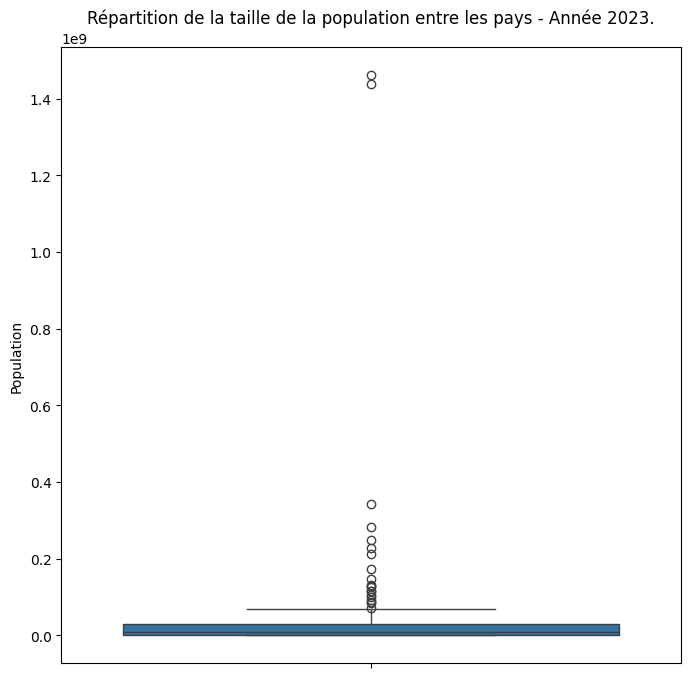

In [115]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='population', data=df_population)
plt.title("Répartition de la taille de la population entre les pays - Année 2023.")
plt.ylabel("Population")

In [116]:
outliers_hauts(df_population, 'population')

Le seuil pour un outlier haut est de :70549997.25


,Pays,population
4,Allemagne,8.454823e+07
19,Bangladesh,1.714670e+08
32,Brésil,2.111407e+08
42,Chine,1.461501e+09
49,Congo (Rép. dém.),1.057897e+08
65,Fédération de Russie,1.454405e+08
85,Inde,1.438070e+09
86,Indonésie,2.811901e+08
87,Iran,9.060871e+07
94,Japon,1.243709e+08


Que des pays très peuplés mais aucune raison de les exclure de l'analyse

In [117]:
df_population.sort_values(by='population', ascending=False).head(10)

,Pays,population
42,Chine,1.461501e+09
85,Inde,1.438070e+09
219,États-Unis d'Amérique,3.434773e+08
86,Indonésie,2.811901e+08
141,Pakistan,2.475045e+08
132,Nigéria,2.278829e+08
32,Brésil,2.111407e+08
19,Bangladesh,1.714670e+08
65,Fédération de Russie,1.454405e+08
121,Mexique,1.297398e+08


Text(0, 0.5, 'Occurences')

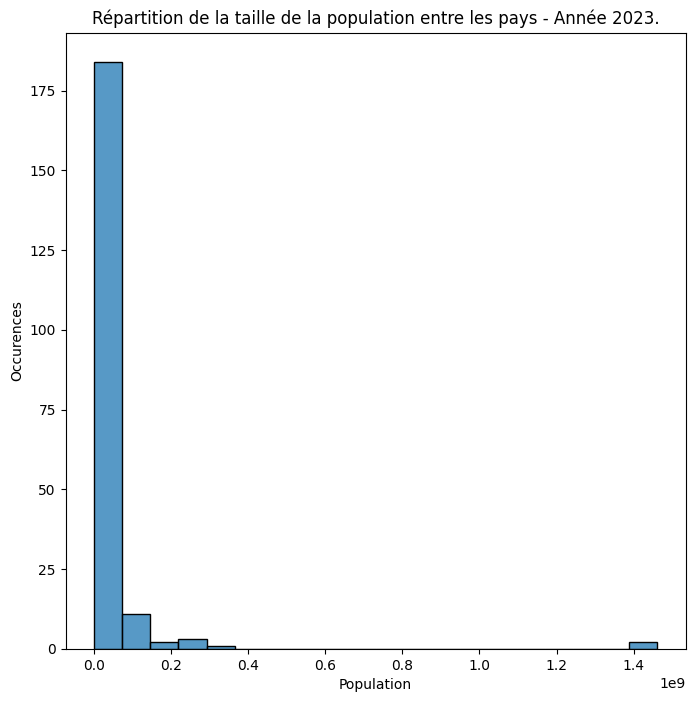

In [118]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_population, x="population", bins=20)
plt.title("Répartition de la taille de la population entre les pays - Année 2023.")
plt.xlabel("Population")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


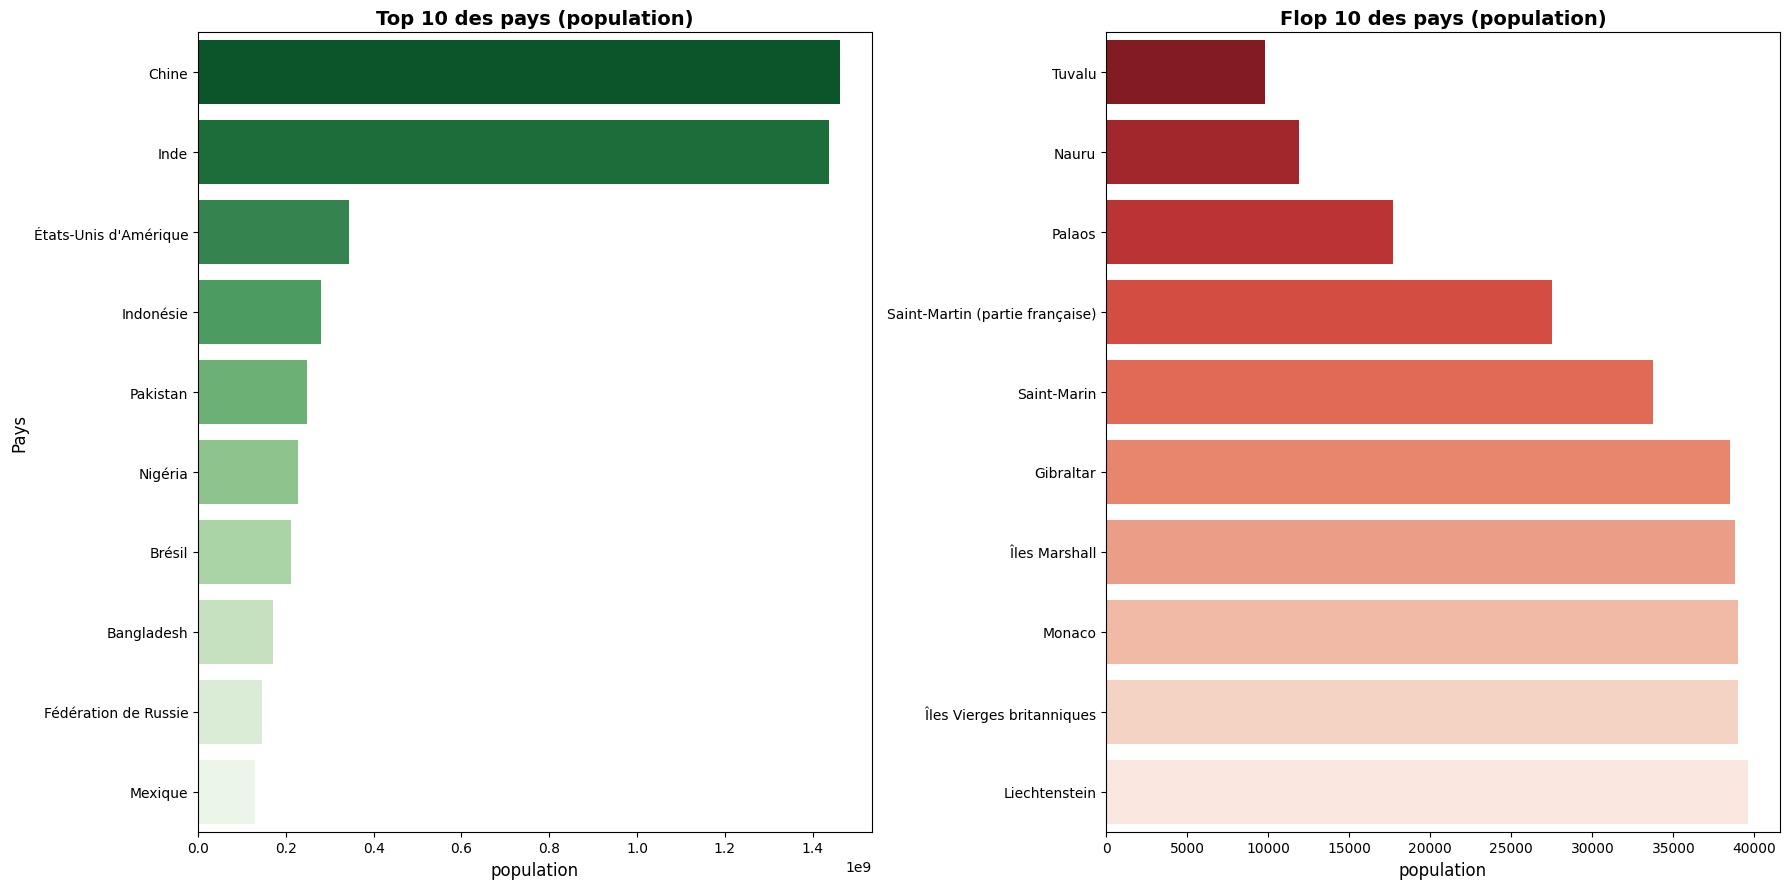

In [119]:
plot_top_flop_10(df_population, 'population')

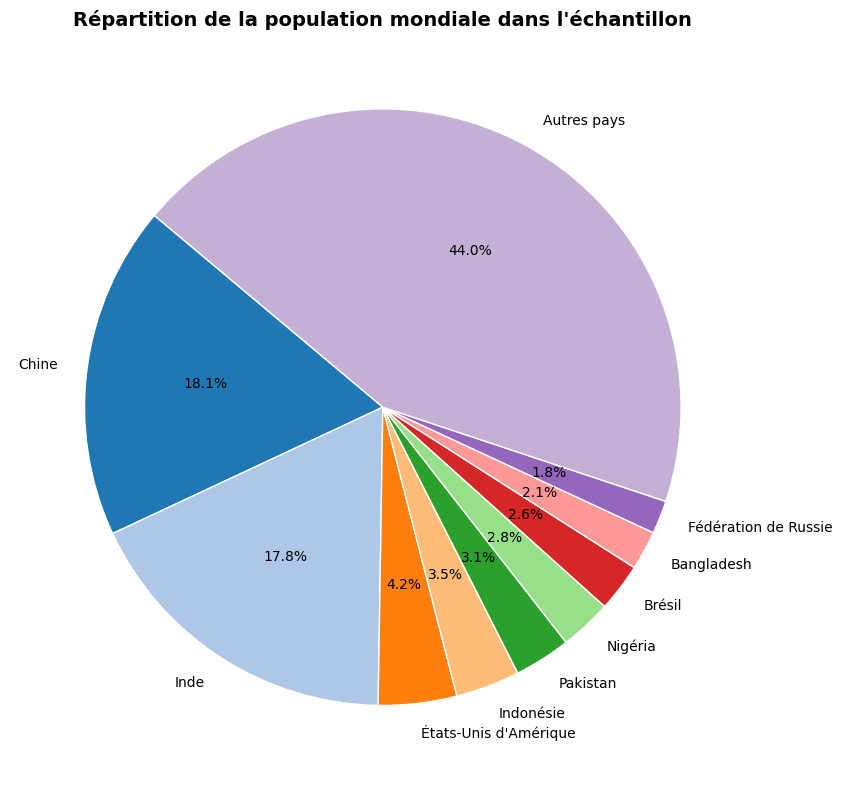

In [120]:
# 1. On trie par population décroissante et on nettoie les NaN
df_sorted = df_population.sort_values(by='population', ascending=False)

# 2. On isole le Top 9
top_9 = df_sorted.head(9).copy()

# 3. On calcule la somme de TOUS les autres pays
autres_pop = df_sorted.iloc[9:]['population'].sum()

# 4. On crée un nouveau DataFrame pour le reste du monde et on fusionne
df_autres = pd.DataFrame([{'Pays': 'Autres pays', 'population': max(0, autres_pop)}])
df_pie = pd.concat([top_9, df_autres], ignore_index=True)

# 5. Génération du Pie Plot
plt.figure(figsize=(10, 8))
plt.pie(
    df_pie['population'], 
    labels=df_pie['Pays'], 
    autopct='%1.1f%%', # Affiche le pourcentage avec une décimale
    startangle=140, 
    colors=plt.cm.tab20.colors, # Palette de couleurs distinctes
    wedgeprops={'edgecolor': 'white', 'linewidth': 1} # Sépare joliment les parts
)

plt.title("Répartition de la population mondiale dans l'échantillon", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_pib</h2>
</div>

In [121]:
df_pib.head()

,Domaine,Zone,Élément,Produit,Année,Unité,Valeur
0,Indicateurs macro,Afghanistan,Valeur US$,Produit Intérieur Brut,1970,Millions d’USD,1748.886597
1,Indicateurs macro,Afghanistan,Valeur US$,Produit Intérieur Brut,1971,Millions d’USD,1831.108982
2,Indicateurs macro,Afghanistan,Valeur US$,Produit Intérieur Brut,1972,Millions d’USD,1595.555482
3,Indicateurs macro,Afghanistan,Valeur US$,Produit Intérieur Brut,1973,Millions d’USD,1733.333275
4,Indicateurs macro,Afghanistan,Valeur US$,Produit Intérieur Brut,1974,Millions d’USD,2155.555500


In [122]:
df_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11049 entries, 0 to 11048
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domaine  11049 non-null  object 
 1   Zone     11049 non-null  object 
 2   Élément  11049 non-null  object 
 3   Produit  11049 non-null  object 
 4   Année    11049 non-null  int64  
 5   Unité    11049 non-null  object 
 6   Valeur   11049 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 604.4+ KB


le fichier a l'air complet, c'est parfait.

In [123]:
#Comme d'habitude, on renomme les colonnes intéressantes et on supprime celles inutiles. Ensuite on filtre sur 2023.
df_pib = df_pib.rename(columns={'Valeur':'PIB', 'Zone' : 'Pays'})
df_pib = df_pib[df_pib['Année'] == 2023]
df_pib = df_pib[['Pays', 'PIB']]
df_pib[ 'PIB'] *= 1_000_000 #multiplication par 10^6 pour passer de millions de $ à $ simples.
df_pib

,Pays,PIB
53,Afghanistan,1.641675e+10
108,Afrique du Sud,3.777816e+11
163,Albanie,2.297767e+10
218,Algérie,2.476262e+11
273,Allemagne,4.525704e+12
...,...,...
10808,Venezuela (République bolivarienne du),1.393949e+11
10863,Viet Nam,4.297170e+11
10899,Yémen,8.757940e+09
10992,Zambie,2.757796e+10


In [124]:
# Comme la colonne pays est déjà en fr, on vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_pib['Pays']) - set(df_corresp['Pays']))
verif_Pays

['République populaire démocratique de Corée',
 'Cabo Verde',
 'Polynésie française',
 'République démocratique du Congo',
 'Sint Maarten (partie néerlandaise)',
 'El Salvador',
 'Érythrée',
 'Chine, continentale',
 'Guinée équatoriale',
 'Venezuela (République bolivarienne du)',
 'Montserrat',
 'Bolivie (État plurinational de)',
 'Chine - RAS de Macao',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago',
 "Iran (République islamique d')",
 'Nouvelle-Calédonie',
 'Arabie saoudite',
 'Îles Caïmanes',
 'Chine - RAS de Hong-Kong',
 'Anguilla',
 'Bélarus',
 'Timor-Leste',
 'Palestine',
 'Micronésie (États fédérés de)',
 'Türkiye',
 'Îles Cook',
 'Myanmar',
 'Saint-Vincent-et-les Grenadines',
 'Brunéi Darussalam']

In [125]:
df_pib[df_pib['Pays'] == 'Chine']

,Pays,PIB


In [126]:
# On uniformise 
df_pib.loc[df_pib['Pays'] == 'Îles Caïmanes', 'Pays'] = 'Îles Caïmans'
df_pib.loc[df_pib['Pays'] == 'Bolivie (État plurinational de)', 'Pays'] = 'Bolivie'
df_pib.loc[df_pib['Pays'] == 'Brunéi Darussalam', 'Pays'] = 'Brunei'
df_pib.loc[df_pib['Pays'] == 'Myanmar', 'Pays'] = 'Birmanie'
df_pib.loc[df_pib['Pays'] == 'République populaire démocratique de Corée', 'Pays'] = 'Corée du Nord'
df_pib.loc[df_pib['Pays'] == 'Guinée équatoriale', 'Pays'] = 'Guinée-Équatoriale'
df_pib.loc[df_pib['Pays'] == 'Cabo Verde', 'Pays'] = 'Cap Vert'
df_pib.loc[df_pib['Pays'] == 'Bélarus', 'Pays'] = 'Biélorussie'
df_pib.loc[df_pib['Pays'] == 'Érythrée', 'Pays'] = 'Erythrée'
df_pib.loc[df_pib['Pays'] == "Iran (République islamique d')", 'Pays'] = 'Iran'
df_pib.loc[df_pib['Pays'] == 'El Salvador', 'Pays'] = 'Salvador'
df_pib.loc[df_pib['Pays'] == 'République démocratique du Congo', 'Pays'] = 'Congo (Rép. dém.)'
df_pib.loc[df_pib['Pays'] == 'Venezuela (République bolivarienne du)', 'Pays'] = 'Venezuela'
df_pib.loc[df_pib['Pays'] == 'Chine, Taiwan Province de', 'Pays'] = 'Taïwan'
df_pib.loc[df_pib['Pays'] == 'Chine, continentale', 'Pays'] = 'Chine'
df_pib.loc[df_pib['Pays'] == 'Palestine', 'Pays'] = 'Territoires palestiniens'
df_pib.loc[df_pib['Pays'] == 'Chine - RAS de Hong-Kong', 'Pays'] = 'Chine'
df_pib.loc[df_pib['Pays'] == 'Türkiye', 'Pays'] = 'Turquie'
df_pib.loc[df_pib['Pays'] == 'Arabie saoudite', 'Pays'] = 'Arabie Saoudite'
verif_Pays = list(set(df_pib['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Nouvelle-Calédonie',
 'Anguilla',
 'Polynésie française',
 'Montserrat',
 'Micronésie (États fédérés de)',
 'Sint Maarten (partie néerlandaise)',
 'Îles Cook',
 'Saint-Vincent-et-les Grenadines',
 'Chine - RAS de Macao',
 'Timor-Leste',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago']

Ne reste que les territoires rattachés à d'autres ou trop petits pour notre analyse.

In [127]:
# Je regroupe les lignes pour la chine
df_pib = df_pib.groupby('Pays')['PIB'].sum().reset_index()

In [128]:
# On ne garde que les Pays qui ont la correspondance
df_pib = df_pib[~df_pib['Pays'].isin(verif_Pays)]

Text(0, 0.5, 'PIB')

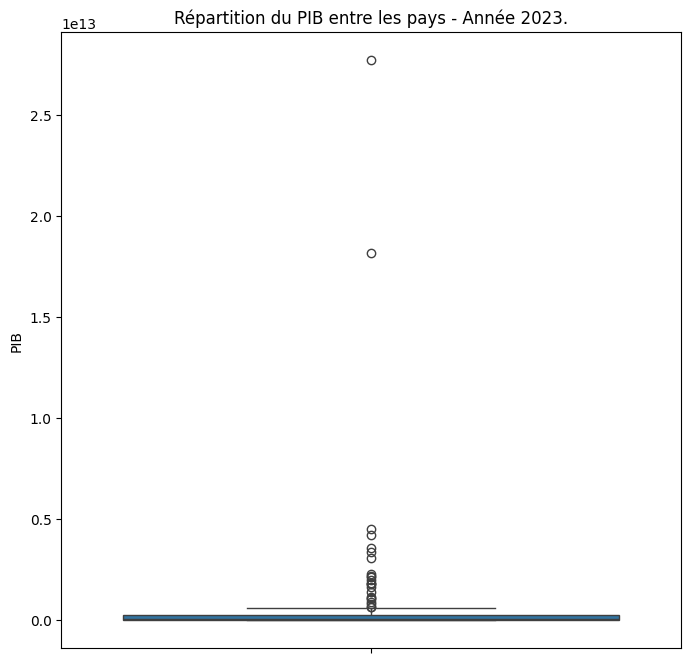

In [129]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='PIB', data=df_pib)
plt.title("Répartition du PIB entre les pays - Année 2023.")
plt.ylabel("PIB")

In [130]:
outliers_hauts(df_pib, 'PIB')

Le seuil pour un outlier haut est de :613985265275.00


,Pays,PIB
4,Allemagne,4.525704e+12
9,Arabie Saoudite,1.067583e+12
10,Argentine,6.460753e+11
13,Australie,1.775628e+12
20,Belgique,6.447828e+11
30,Brésil,2.191132e+12
37,Canada,2.142471e+12
40,Chine,1.817559e+13
57,Espagne,1.620091e+12
62,France,3.051832e+12


In [131]:
df_pib.sort_values(by='PIB', ascending=False).head(10)

,Pays,PIB
201,États-Unis d'Amérique,2.772070e+13
40,Chine,1.817559e+13
4,Allemagne,4.525704e+12
88,Japon,4.204495e+12
79,Inde,3.575778e+12
146,Royaume-Uni de Grande-Bretagne et d'Irlande du...,3.380855e+12
62,France,3.051832e+12
86,Italie,2.300941e+12
30,Brésil,2.191132e+12
37,Canada,2.142471e+12


Text(0, 0.5, 'Occurences')

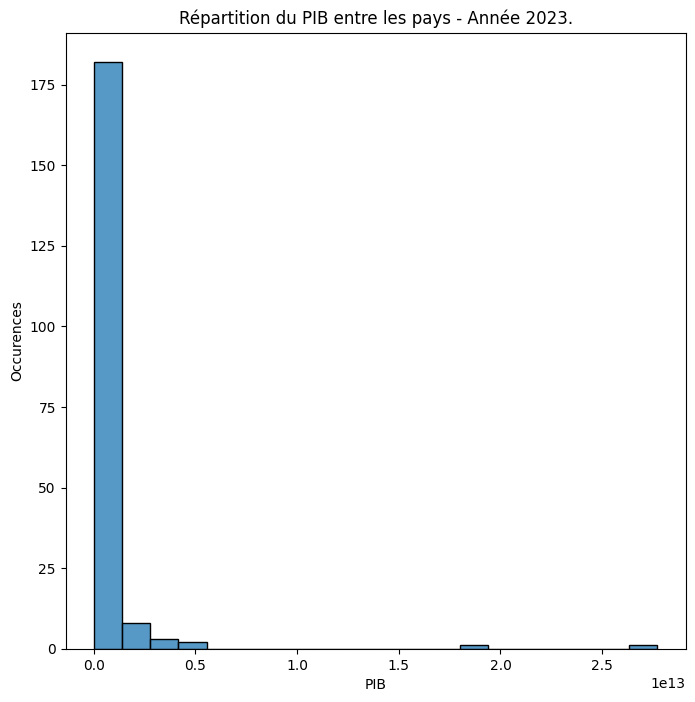

In [132]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_pib, x="PIB", bins=20)
plt.title("Répartition du PIB entre les pays - Année 2023.")
plt.xlabel("PIB")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


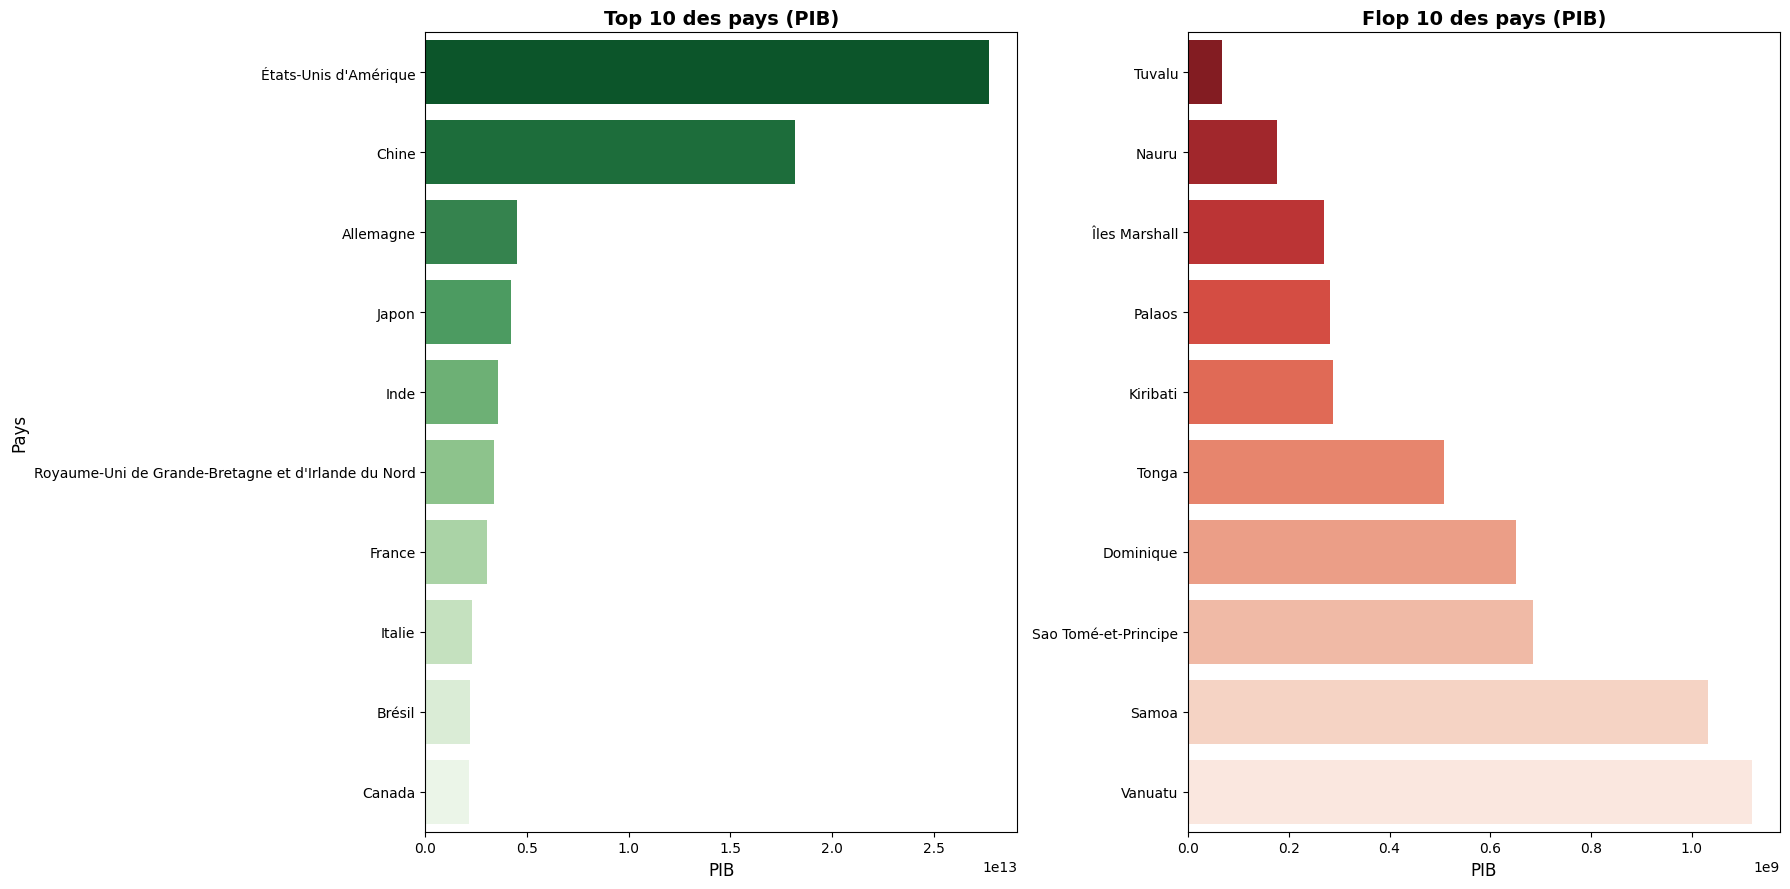

In [133]:
plot_top_flop_10(df_pib, 'PIB')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_nourriture</h2>
</div>

In [134]:
df_consommation_poulet.head()

,Domaine,Zone,Élément,Produit,Année,Unité,Valeur
0,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Disponibilité alimentaire en quantité (tonnes),"Viande, poulet, fraîche ou réfrigérée",2010,tonnes,64538.38
1,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Disponibilité alimentaire en quantité (tonnes),"Viande, poulet, fraîche ou réfrigérée",2011,tonnes,56121.71
2,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Disponibilité alimentaire en quantité (tonnes),"Viande, poulet, fraîche ou réfrigérée",2012,tonnes,62405.56
3,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Disponibilité alimentaire en quantité (tonnes),"Viande, poulet, fraîche ou réfrigérée",2013,tonnes,66510.55
4,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Disponibilité alimentaire en quantité (tonnes),"Viande, poulet, fraîche ou réfrigérée",2014,tonnes,68235.20


In [135]:
df_consommation_poulet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2425 entries, 0 to 2424
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domaine  2425 non-null   object 
 1   Zone     2425 non-null   object 
 2   Élément  2425 non-null   object 
 3   Produit  2425 non-null   object 
 4   Année    2425 non-null   int64  
 5   Unité    2425 non-null   object 
 6   Valeur   2425 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 132.7+ KB


le fichier a l'air complet, c'est parfait.

In [136]:
#Comme d'habitude, on renomme les colonnes intéressantes et on supprime celles inutiles. Ensuite on filtre sur 2023.
df_consommation_poulet = df_consommation_poulet.rename(columns={'Valeur':'consommation_poulet', 'Zone' : 'Pays'})
df_consommation_poulet = df_consommation_poulet[df_consommation_poulet['Année'] == 2023]
df_consommation_poulet = df_consommation_poulet[['Pays', 'consommation_poulet']]
df_consommation_poulet[ 'consommation_poulet'] *= 1000 #passage de tonnes à kgs
df_consommation_poulet

,Pays,consommation_poulet
13,Afghanistan,3.293683e+07
27,Afrique du Sud,2.122618e+09
41,Albanie,6.465976e+07
55,Algérie,4.211345e+08
69,Allemagne,9.402329e+08
...,...,...
2368,Venezuela (République bolivarienne du),5.000410e+08
2382,Viet Nam,1.775302e+09
2396,Yémen,3.205886e+08
2410,Zambie,6.972676e+07


In [137]:
# Comme la colonne pays est déjà en fr, on vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_consommation_poulet['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Cabo Verde',
 'Polynésie française',
 'République démocratique du Congo',
 'El Salvador',
 'Chine, continentale',
 'Venezuela (République bolivarienne du)',
 'Bolivie (État plurinational de)',
 'Chine - RAS de Macao',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago',
 'Chine, Taiwan Province de',
 "Iran (République islamique d')",
 'Nouvelle-Calédonie',
 'Arabie saoudite',
 'Chine - RAS de Hong-Kong',
 'Bélarus',
 'Timor-Leste',
 'Micronésie (États fédérés de)',
 'Türkiye',
 'Myanmar',
 'Saint-Vincent-et-les Grenadines']

In [138]:
# On uniformise 
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Bolivie (État plurinational de)', 'Pays'] = 'Bolivie'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Myanmar', 'Pays'] = 'Birmanie'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'République populaire démocratique de Corée', 'Pays'] = 'Corée du Nord'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Cabo Verde', 'Pays'] = 'Cap Vert'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Bélarus', 'Pays'] = 'Biélorussie'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == "Iran (République islamique d')", 'Pays'] = 'Iran'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'El Salvador', 'Pays'] = 'Salvador'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'République démocratique du Congo', 'Pays'] = 'Congo (Rép. dém.)'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Venezuela (République bolivarienne du)', 'Pays'] = 'Venezuela'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Chine, Taiwan Province de', 'Pays'] = 'Taïwan'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Chine - RAS de Hong-Kong', 'Pays'] = 'Chine'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Türkiye', 'Pays'] = 'Turquie'
df_consommation_poulet.loc[df_consommation_poulet['Pays'] == 'Arabie saoudite', 'Pays'] = 'Arabie Saoudite'
verif_Pays = list(set(df_consommation_poulet['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Nouvelle-Calédonie',
 'Polynésie française',
 'Micronésie (États fédérés de)',
 'Saint-Vincent-et-les Grenadines',
 'Chine - RAS de Macao',
 'Timor-Leste',
 'Chine, continentale',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago']

In [139]:
# Je regroupe les lignes pour la chine
df_consommation_poulet = df_consommation_poulet.groupby('Pays')['consommation_poulet'].sum().reset_index()

In [140]:
# On ne garde que les Pays qui ont la correspondance
df_consommation_poulet = df_consommation_poulet[~df_consommation_poulet['Pays'].isin(verif_Pays)]

Text(0, 0.5, 'Consommation de poulet(en tonnes)')

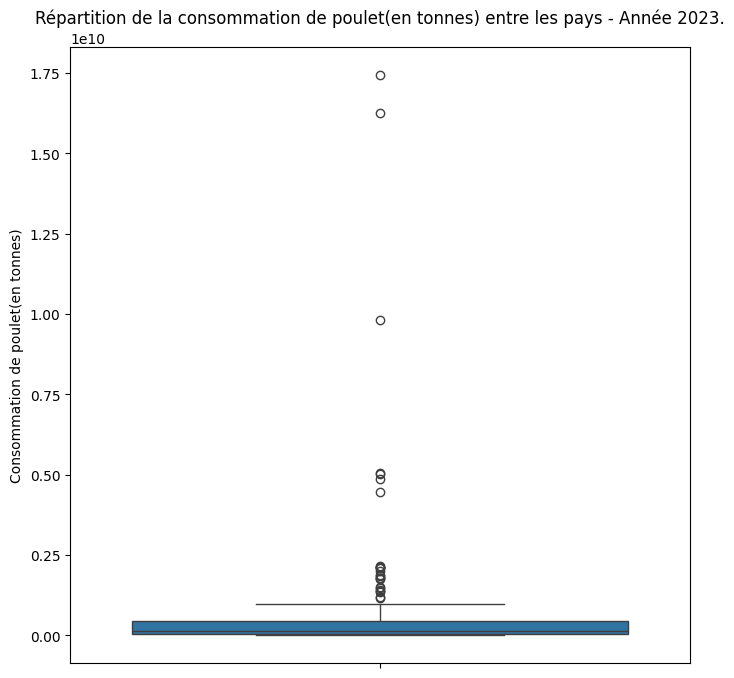

In [141]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='consommation_poulet', data=df_consommation_poulet)
plt.title("Répartition de la consommation de poulet(en tonnes) entre les pays - Année 2023.")
plt.ylabel("Consommation de poulet(en tonnes)")

In [142]:
outliers_hauts(df_consommation_poulet, 'consommation_poulet')

Le seuil pour un outlier haut est de :1048406147.50


,Pays,consommation_poulet
1,Afrique du Sud,2.122618e+09
7,Arabie Saoudite,1.409702e+09
8,Argentine,2.079712e+09
10,Australie,1.355272e+09
25,Brésil,9.820763e+09
30,Canada,1.483480e+09
33,Chine,1.743106e+10
37,Colombie,1.859218e+09
46,Espagne,1.371101e+09
51,France,1.181666e+09


In [143]:
df_consommation_poulet.sort_values(by='consommation_poulet', ascending=False).head(10)

,Pays,consommation_poulet
33,Chine,1.743106e+10
172,États-Unis d'Amérique,1.625247e+10
25,Brésil,9.820763e+09
52,Fédération de Russie,5.038424e+09
66,Inde,5.014749e+09
97,Mexique,4.855235e+09
67,Indonésie,4.443030e+09
114,Pakistan,2.153704e+09
1,Afrique du Sud,2.122618e+09
68,Iran,2.115176e+09


Text(0, 0.5, 'Occurences')

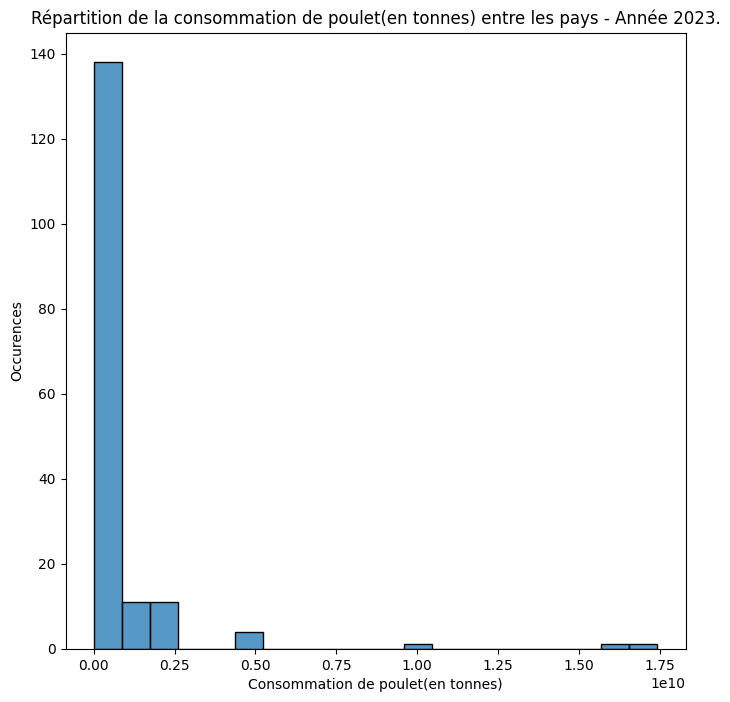

In [144]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_consommation_poulet, x="consommation_poulet", bins=20)
plt.title("Répartition de la consommation de poulet(en tonnes) entre les pays - Année 2023.")
plt.xlabel("Consommation de poulet(en tonnes)")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


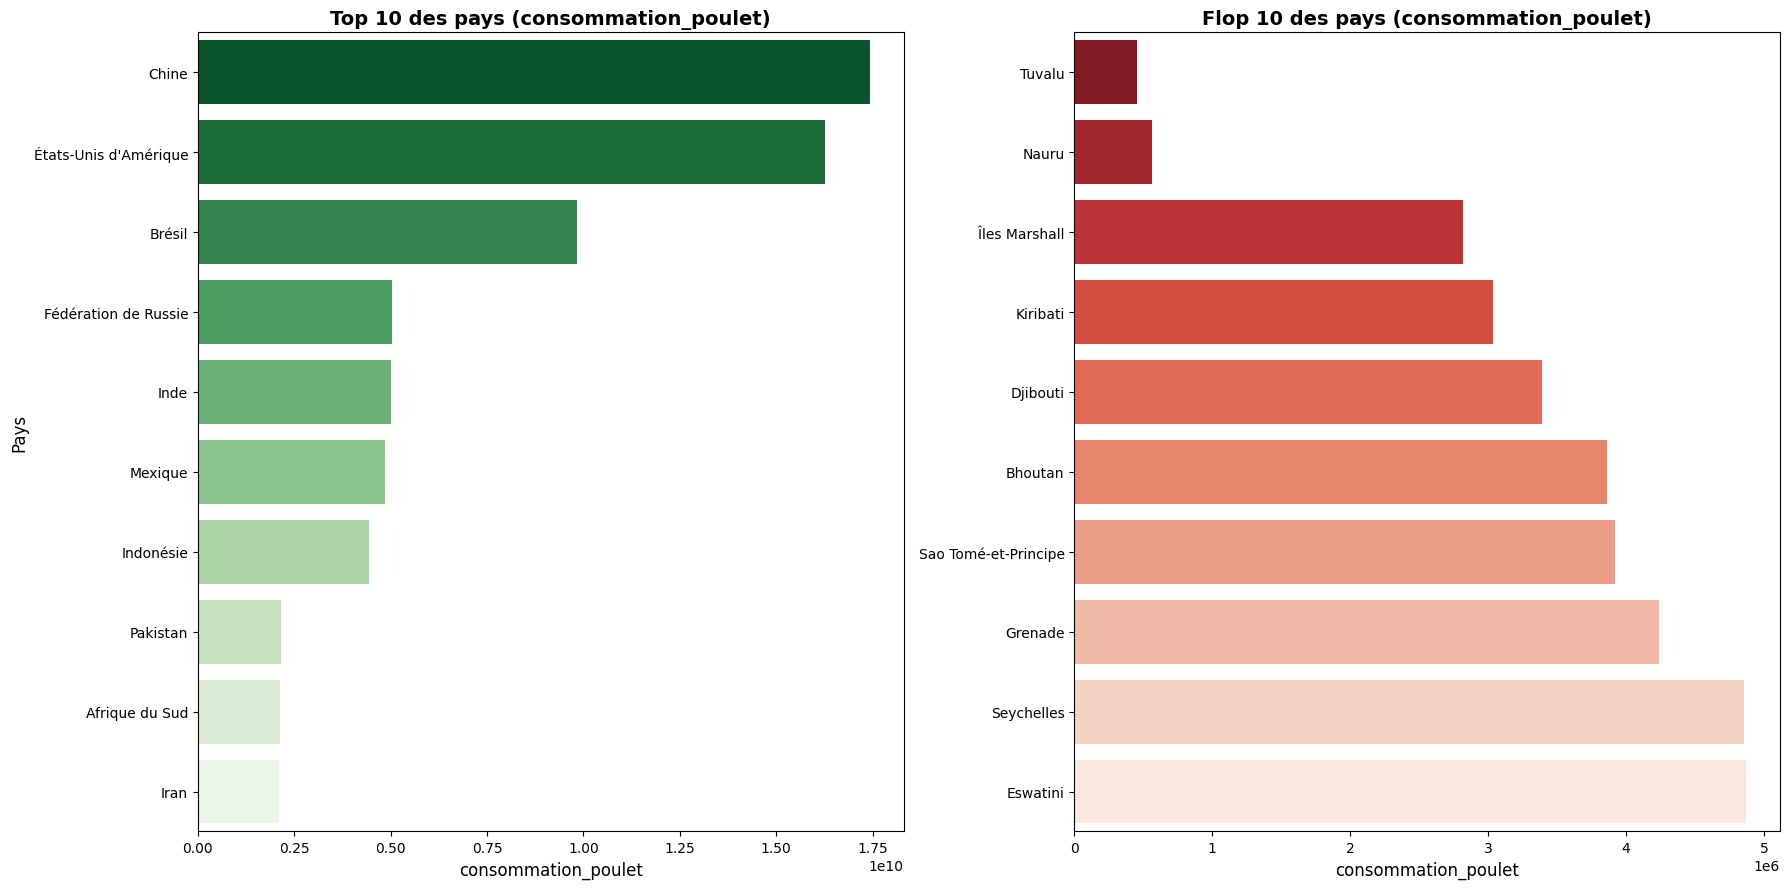

In [145]:
plot_top_flop_10(df_consommation_poulet, 'consommation_poulet')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">df_importation_poulet</h2>
</div>

In [146]:
df_importation_poulet.head()

,Domaine,Zone,Élément,Produit,Année,Unité,Valeur
0,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Importations - quantité,"Viande, poulet, fraîche ou réfrigérée",2010,tonnes,38591.0
1,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Importations - quantité,"Viande, poulet, fraîche ou réfrigérée",2011,tonnes,51004.0
2,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Importations - quantité,"Viande, poulet, fraîche ou réfrigérée",2012,tonnes,21750.0
3,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Importations - quantité,"Viande, poulet, fraîche ou réfrigérée",2013,tonnes,48389.0
4,Compte Disponibilités et Utilisations (CDU) (2...,Afghanistan,Importations - quantité,"Viande, poulet, fraîche ou réfrigérée",2014,tonnes,42300.0


In [147]:
df_importation_poulet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2365 entries, 0 to 2364
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domaine  2365 non-null   object 
 1   Zone     2365 non-null   object 
 2   Élément  2365 non-null   object 
 3   Produit  2365 non-null   object 
 4   Année    2365 non-null   int64  
 5   Unité    2365 non-null   object 
 6   Valeur   2363 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 129.5+ KB


le fichier a l'air complet, c'est parfait.

In [148]:
#Comme d'habitude, on renomme les colonnes intéressantes et on supprime celles inutiles. Ensuite on filtre sur 2023.
df_importation_poulet = df_importation_poulet.rename(columns={'Valeur':'import_poulet', 'Zone' : 'Pays'})
df_importation_poulet = df_importation_poulet[df_importation_poulet['Année'] == 2023]
df_importation_poulet = df_importation_poulet[['Pays', 'import_poulet']]
df_importation_poulet[ 'import_poulet'] *= 1000 #passage de tonnes à kgs
df_importation_poulet

,Pays,import_poulet
13,Afghanistan,4811260.0
27,Afrique du Sud,312852140.0
41,Albanie,47933760.0
52,Algérie,28060.0
66,Allemagne,492941640.0
...,...,...
2308,Venezuela (République bolivarienne du),192520.0
2322,Viet Nam,236321760.0
2336,Yémen,116791590.0
2350,Zambie,22622430.0


In [149]:
# Comme la colonne pays est déjà en fr, on vérifie ceux qui n'ont pas de correspondances
verif_Pays = list(set(df_importation_poulet['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Cabo Verde',
 'Polynésie française',
 'République démocratique du Congo',
 'El Salvador',
 'Chine, continentale',
 'Venezuela (République bolivarienne du)',
 'Bolivie (État plurinational de)',
 'Chine - RAS de Macao',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago',
 'Chine, Taiwan Province de',
 "Iran (République islamique d')",
 'Nouvelle-Calédonie',
 'Arabie saoudite',
 'Chine - RAS de Hong-Kong',
 'Bélarus',
 'Timor-Leste',
 'Micronésie (États fédérés de)',
 'Türkiye',
 'Saint-Vincent-et-les Grenadines']

In [150]:
# On uniformise 
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Bolivie (État plurinational de)', 'Pays'] = 'Bolivie'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Myanmar', 'Pays'] = 'Birmanie'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'République populaire démocratique de Corée', 'Pays'] = 'Corée du Nord'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Cabo Verde', 'Pays'] = 'Cap Vert'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Bélarus', 'Pays'] = 'Biélorussie'
df_importation_poulet.loc[df_importation_poulet['Pays'] == "Iran (République islamique d')", 'Pays'] = 'Iran'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'El Salvador', 'Pays'] = 'Salvador'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'République démocratique du Congo', 'Pays'] = 'Congo (Rép. dém.)'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Venezuela (République bolivarienne du)', 'Pays'] = 'Venezuela'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Chine, Taiwan Province de', 'Pays'] = 'Taïwan'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Chine - RAS de Hong-Kong', 'Pays'] = 'Chine'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Türkiye', 'Pays'] = 'Turquie'
df_importation_poulet.loc[df_importation_poulet['Pays'] == 'Arabie saoudite', 'Pays'] = 'Arabie Saoudite'
verif_Pays = list(set(df_importation_poulet['Pays']) - set(df_corresp['Pays']))
verif_Pays

['Nouvelle-Calédonie',
 'Polynésie française',
 'Micronésie (États fédérés de)',
 'Saint-Vincent-et-les Grenadines',
 'Chine - RAS de Macao',
 'Timor-Leste',
 'Chine, continentale',
 'Saint-Kitts-et-Nevis',
 'Trinité-et-Tobago']

In [151]:
# Je regroupe les lignes pour la chine
df_importation_poulet = df_importation_poulet.groupby('Pays')['import_poulet'].sum().reset_index()

In [152]:
# On ne garde que les Pays qui ont la correspondance
df_importation_poulet = df_importation_poulet[~df_importation_poulet['Pays'].isin(verif_Pays)]

Text(0, 0.5, 'Importation de poulet(en tonnes)')

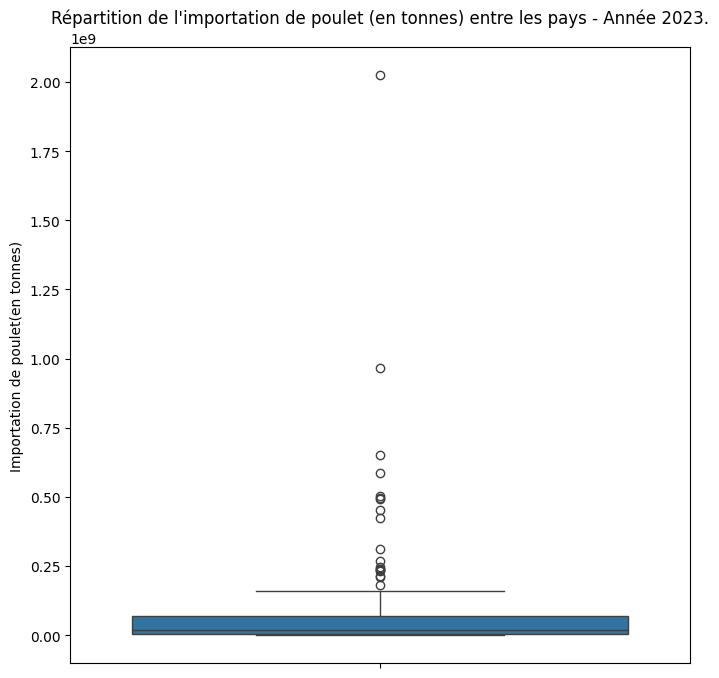

In [153]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='import_poulet', data=df_importation_poulet)
plt.title("Répartition de l'importation de poulet (en tonnes) entre les pays - Année 2023.")
plt.ylabel("Importation de poulet(en tonnes)")

In [154]:
outliers_hauts(df_importation_poulet, 'import_poulet')

Le seuil pour un outlier haut est de :167228583.75


,Pays,import_poulet
1,Afrique du Sud,3.128521e+08
4,Allemagne,4.929416e+08
5,Angola,2.095619e+08
7,Arabie Saoudite,4.242751e+08
17,Belgique,1.830032e+08
32,Chine,2.024951e+09
38,Congo,2.137398e+08
50,France,4.952531e+08
54,Ghana,2.310245e+08
68,Iraq,5.047320e+08


In [155]:
df_importation_poulet.sort_values(by='import_poulet', ascending=False).head(10)

,Pays,import_poulet
32,Chine,2.024951e+09
96,Mexique,9.671124e+08
115,Pays-Bas (Royaume des),6.526206e+08
167,Émirats arabes unis,5.850250e+08
68,Iraq,5.047320e+08
50,France,4.952531e+08
4,Allemagne,4.929416e+08
123,Royaume-Uni de Grande-Bretagne et d'Irlande du...,4.518300e+08
7,Arabie Saoudite,4.242751e+08
1,Afrique du Sud,3.128521e+08


Text(0, 0.5, 'Occurences')

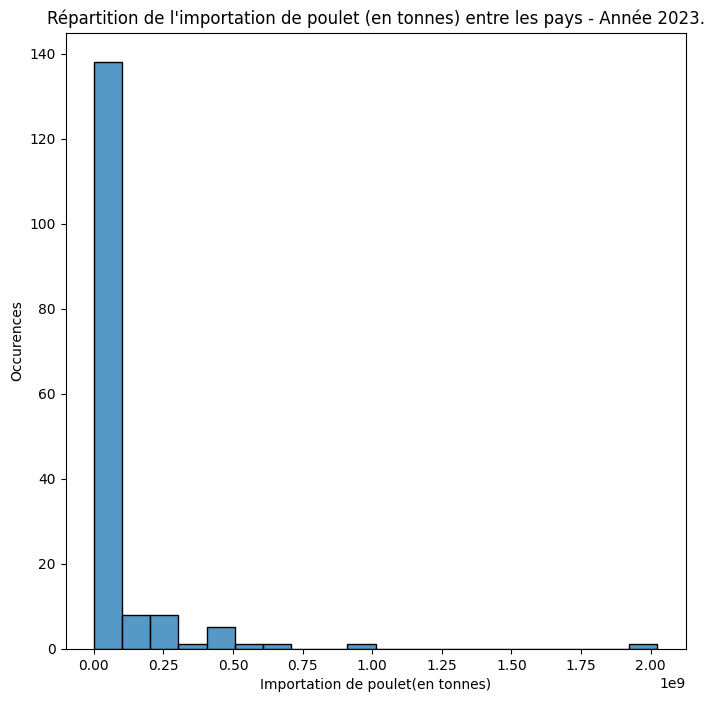

In [156]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_importation_poulet, x="import_poulet", bins=20)
plt.title("Répartition de l'importation de poulet (en tonnes) entre les pays - Année 2023.")
plt.xlabel("Importation de poulet(en tonnes)")
plt.ylabel("Occurences")

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


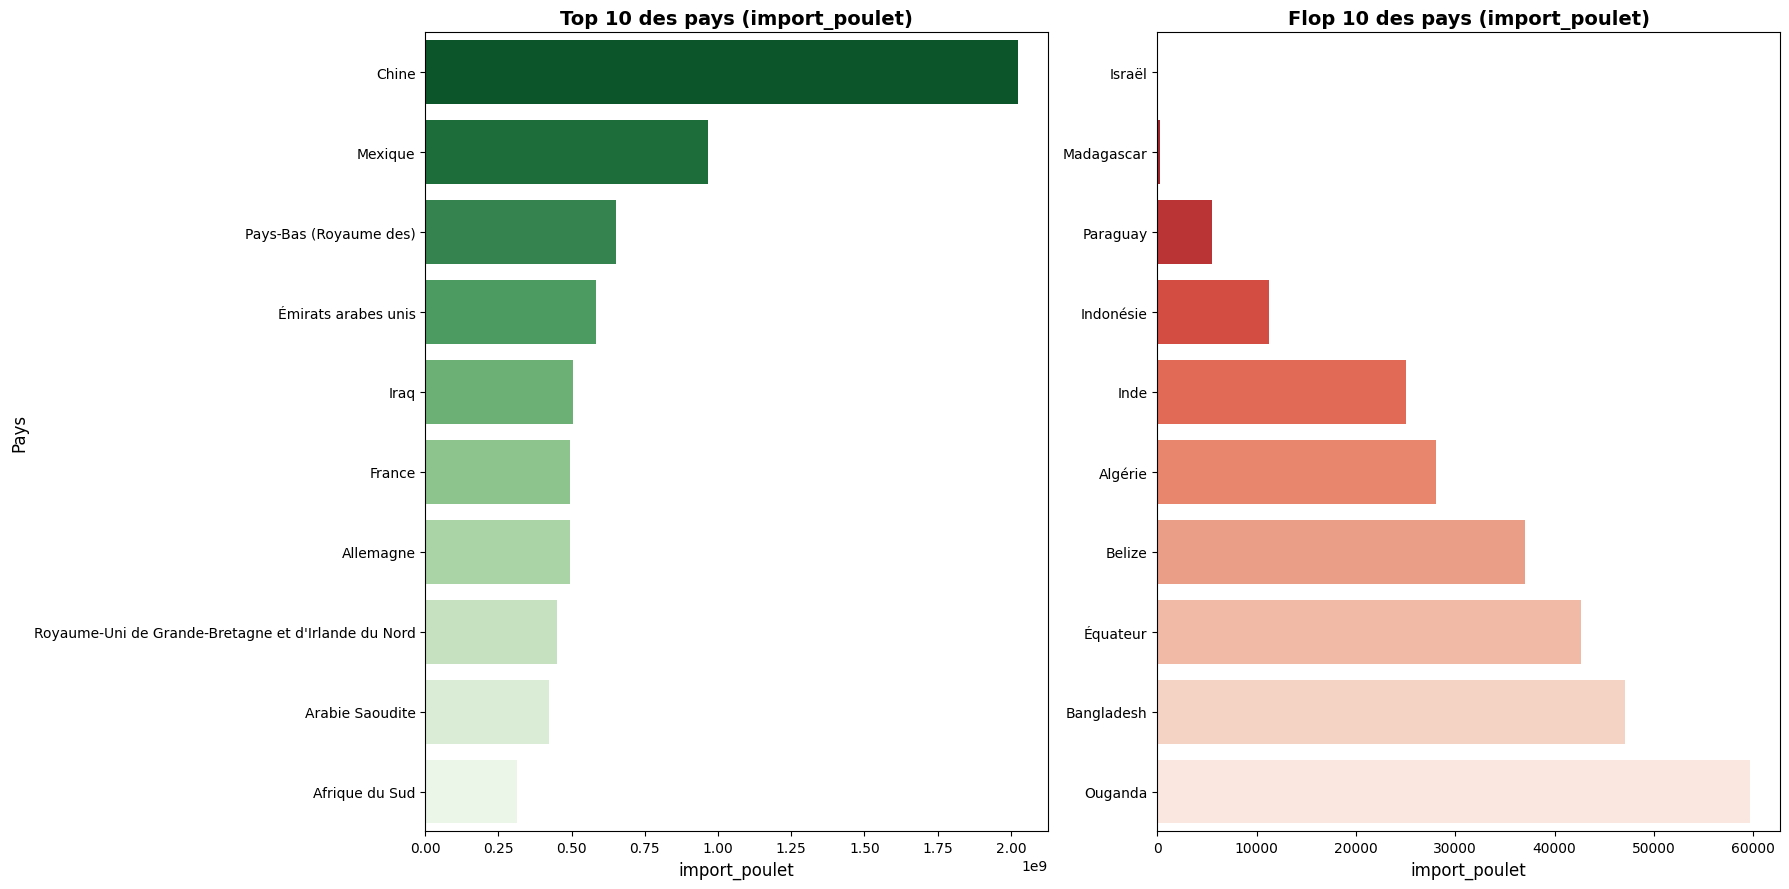

In [157]:
plot_top_flop_10(df_importation_poulet, 'import_poulet')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Merge des fichiers</h2>
</div>

In [158]:
# On prépare la base principale
df_final = df_population.copy()

# Liste finale ordonnée de tous les autres indicateurs à fusionner
autres_dfs = [
    df_idh, df_pib, df_importation_poulet,
    df_politic, df_elec, df_lpi, df_consommation_poulet, df_dist
]

for df in autres_dfs:
    df_temp = df.copy()
    
    # Fusion
    df_final = pd.merge(df_final, df_temp, on='Pays', how='left')


# Relance la vérification du taux de NaN
print("Nouveau taux de NaN par indicateur :")
print(df_final.isnull().mean() * 100)

Nouveau taux de NaN par indicateur :
Pays                    0.000000
population              0.000000
IDH                     8.374384
PIB                     3.940887
import_poulet          19.211823
Politic_score          16.256158
Access_Elec_Pct         0.985222
LPI                    18.719212
consommation_poulet    17.733990
dist                    5.911330
dtype: float64


In [159]:
df_final.duplicated().sum()

np.int64(0)

In [160]:
df_final.head(50)

,Pays,population,IDH,PIB,import_poulet,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist
0,Afghanistan,4.145476e+07,0.496,1.641675e+10,4.811260e+06,2.485,85.3,1.900000,3.293683e+07,5590.3810
1,Afrique du Sud,6.321238e+07,0.741,3.777816e+11,3.128521e+08,0.298,87.7,3.700000,2.122618e+09,9353.5520
2,Albanie,2.811655e+06,0.810,2.297767e+10,4.793376e+07,-0.622,100.0,2.500000,6.465976e+07,1603.5340
3,Algérie,4.616422e+07,0.763,2.476262e+11,2.806000e+04,-1.563,100.0,2.500000,4.211345e+08,1340.3900
4,Allemagne,8.454823e+07,0.959,4.525704e+12,4.929416e+08,0.004,100.0,4.100000,9.402329e+08,439.8984
5,Andorre,8.085600e+04,0.913,3.785067e+09,NaN,NaN,100.0,NaN,NaN,711.5485
6,Angola,3.674991e+07,0.616,9.055216e+10,2.095619e+08,-0.644,51.1,2.100000,2.697983e+08,6510.3220
7,Antigua-et-Barbuda,9.331600e+04,0.851,2.033085e+09,6.223520e+06,NaN,100.0,2.900000,5.738130e+06,6708.7700
8,Arabie Saoudite,3.326429e+07,0.900,1.067583e+12,4.242751e+08,-1.695,100.0,3.400000,1.409702e+09,4694.5000
9,Argentine,4.553840e+07,0.865,6.460753e+11,1.860920e+06,1.901,100.0,2.800000,2.079712e+09,11072.2500


In [161]:
# Supprime toutes les lignes contenant au moins une valeur manquante (NaN)
df_final = df_final.dropna()

# Vérification : tout doit être à 0% !
print(df_final.isnull().mean() * 100)
print(f"Nombre de Pays restants : {df_final['Pays'].nunique()}")
print(f"Population couverte : {df_final['population'].sum()/1_000_000_000:.2f} milliards de personnes.")


Pays                   0.0
population             0.0
IDH                    0.0
PIB                    0.0
import_poulet          0.0
Politic_score          0.0
Access_Elec_Pct        0.0
LPI                    0.0
consommation_poulet    0.0
dist                   0.0
dtype: float64
Nombre de Pays restants : 143
Population couverte : 7.57 milliards de personnes.


In [162]:
# Je veux ajouter le continent dans mon Dataframe, cela me sera utile pour mon k-means

import pycountry_convert as pc

# ajout du code pays dans df_final

df_final['Code'] = df_final['Pays']
df_final['Code'] = df_final['Code'].replace(dict_fr_to_code)

# On crée une fonction pour convertir
def country_to_continent(country_code_iso3):
    try:
        country_alpha2 = pc.country_alpha3_to_country_alpha2(country_code_iso3)
        country_continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        country_continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
        return country_continent_name
    except:
        return "Inconnu"

# 3. Application sur la colonne Code
df_final['Continent'] = df_final['Code'].apply(country_to_continent)

df_final = df_final.drop(columns='Code')

# 4. Vérification
print(df_final[['Pays', 'Continent']].head(5))
df_final.loc[df_final['Continent'] == 'Inconnu', 'Pays']

             Pays Continent
0     Afghanistan      Asia
1  Afrique du Sud    Africa
2         Albanie    Europe
3         Algérie    Africa
4       Allemagne    Europe


Series([], Name: Pays, dtype: object)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Modification des variables PIb, importation et consommation à leur poid par habitant</h2>
</div>

In [163]:
df_final

,Pays,population,IDH,PIB,import_poulet,Politic_score,Access_Elec_Pct,LPI,consommation_poulet,dist,Continent
0,Afghanistan,41454761.0,0.496,1.641675e+10,4811260.0,2.485,85.3,1.900000,3.293683e+07,5590.3810,Asia
1,Afrique du Sud,63212384.0,0.741,3.777816e+11,312852140.0,0.298,87.7,3.700000,2.122618e+09,9353.5520,Africa
2,Albanie,2811655.0,0.810,2.297767e+10,47933760.0,-0.622,100.0,2.500000,6.465976e+07,1603.5340,Europe
3,Algérie,46164219.0,0.763,2.476262e+11,28060.0,-1.563,100.0,2.500000,4.211345e+08,1340.3900,Africa
4,Allemagne,84548231.0,0.959,4.525704e+12,492941640.0,0.004,100.0,4.100000,9.402329e+08,439.8984,Europe
...,...,...,...,...,...,...,...,...,...,...,...
191,Émirats arabes unis,10642081.0,0.940,5.141304e+11,585025000.0,-1.457,100.0,4.000000,4.889619e+08,5249.5350,Asia
192,Équateur,17980083.0,0.777,1.188448e+11,42610.0,0.673,98.7,2.880000,5.632484e+08,9367.0980,South America
193,États-Unis d'Amérique,343477335.0,0.938,2.772070e+13,60044580.0,1.454,100.0,3.800000,1.625247e+10,5838.1570,North America
194,Éthiopie,128691692.0,0.497,1.597465e+11,135200.0,1.612,55.4,2.376767,6.447745e+07,5582.5020,Africa


In [164]:
df_final['PIB'] = df_final['PIB'] / df_final['population']
df_final['import_poulet'] = df_final['import_poulet'] / df_final['population']
df_final['consommation_poulet'] = df_final['consommation_poulet'] / df_final['population']
df_final = df_final.rename(columns={'PIB' : 'PIB_par_habitant', 'import_poulet' : 'import_kg_poulet_par_habitant', 'consommation_poulet' : 'consommation_kg_poulet_par_habitant'})

In [165]:
df_final

,Pays,population,IDH,PIB_par_habitant,import_kg_poulet_par_habitant,Politic_score,Access_Elec_Pct,LPI,consommation_kg_poulet_par_habitant,dist,Continent
0,Afghanistan,41454761.0,0.496,396.015997,0.116060,2.485,85.3,1.900000,0.794525,5590.3810,Asia
1,Afrique du Sud,63212384.0,0.741,5976.385851,4.949222,0.298,87.7,3.700000,33.579152,9353.5520,Africa
2,Albanie,2811655.0,0.810,8172.294966,17.048237,-0.622,100.0,2.500000,22.997046,1603.5340,Europe
3,Algérie,46164219.0,0.763,5364.027937,0.000608,-1.563,100.0,2.500000,9.122530,1340.3900,Africa
4,Allemagne,84548231.0,0.959,53528.073268,5.830301,0.004,100.0,4.100000,11.120669,439.8984,Europe
...,...,...,...,...,...,...,...,...,...,...,...
191,Émirats arabes unis,10642081.0,0.940,48311.080573,54.972801,-1.457,100.0,4.000000,45.946080,5249.5350,Asia
192,Équateur,17980083.0,0.777,6609.804126,0.002370,0.673,98.7,2.880000,31.326240,9367.0980,South America
193,États-Unis d'Amérique,343477335.0,0.938,80706.052992,0.174814,1.454,100.0,3.800000,47.317442,5838.1570,North America
194,Éthiopie,128691692.0,0.497,1241.311299,0.001051,1.612,55.4,2.376767,0.501023,5582.5020,Africa


C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


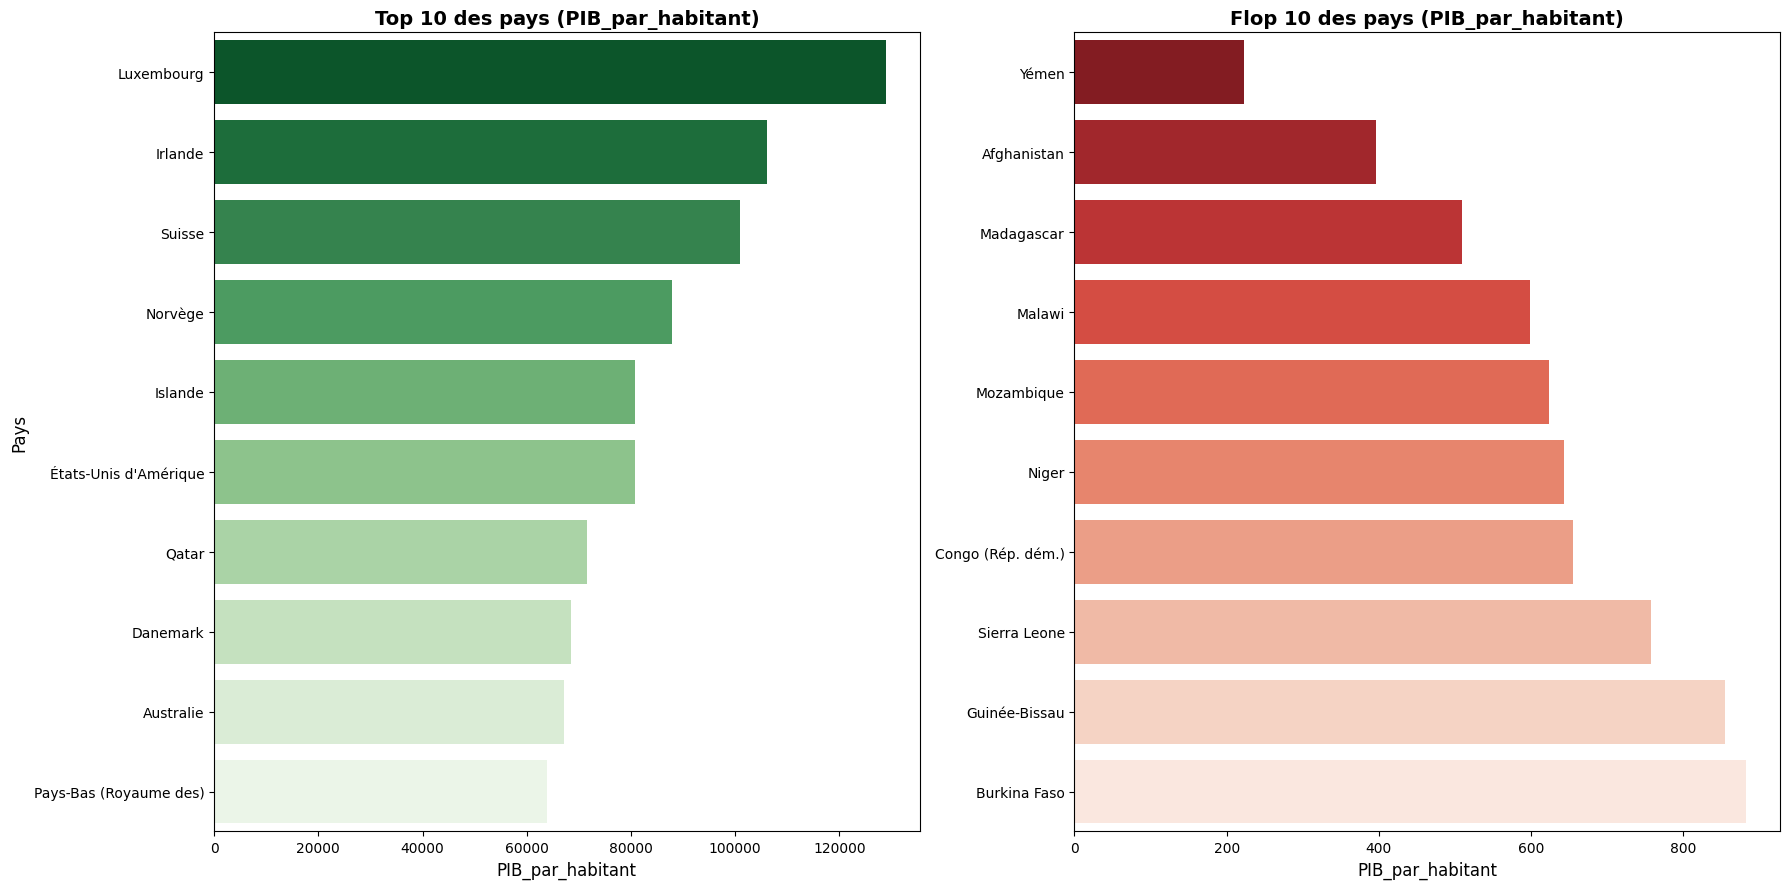

In [166]:
plot_top_flop_10(df_final, 'PIB_par_habitant')

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


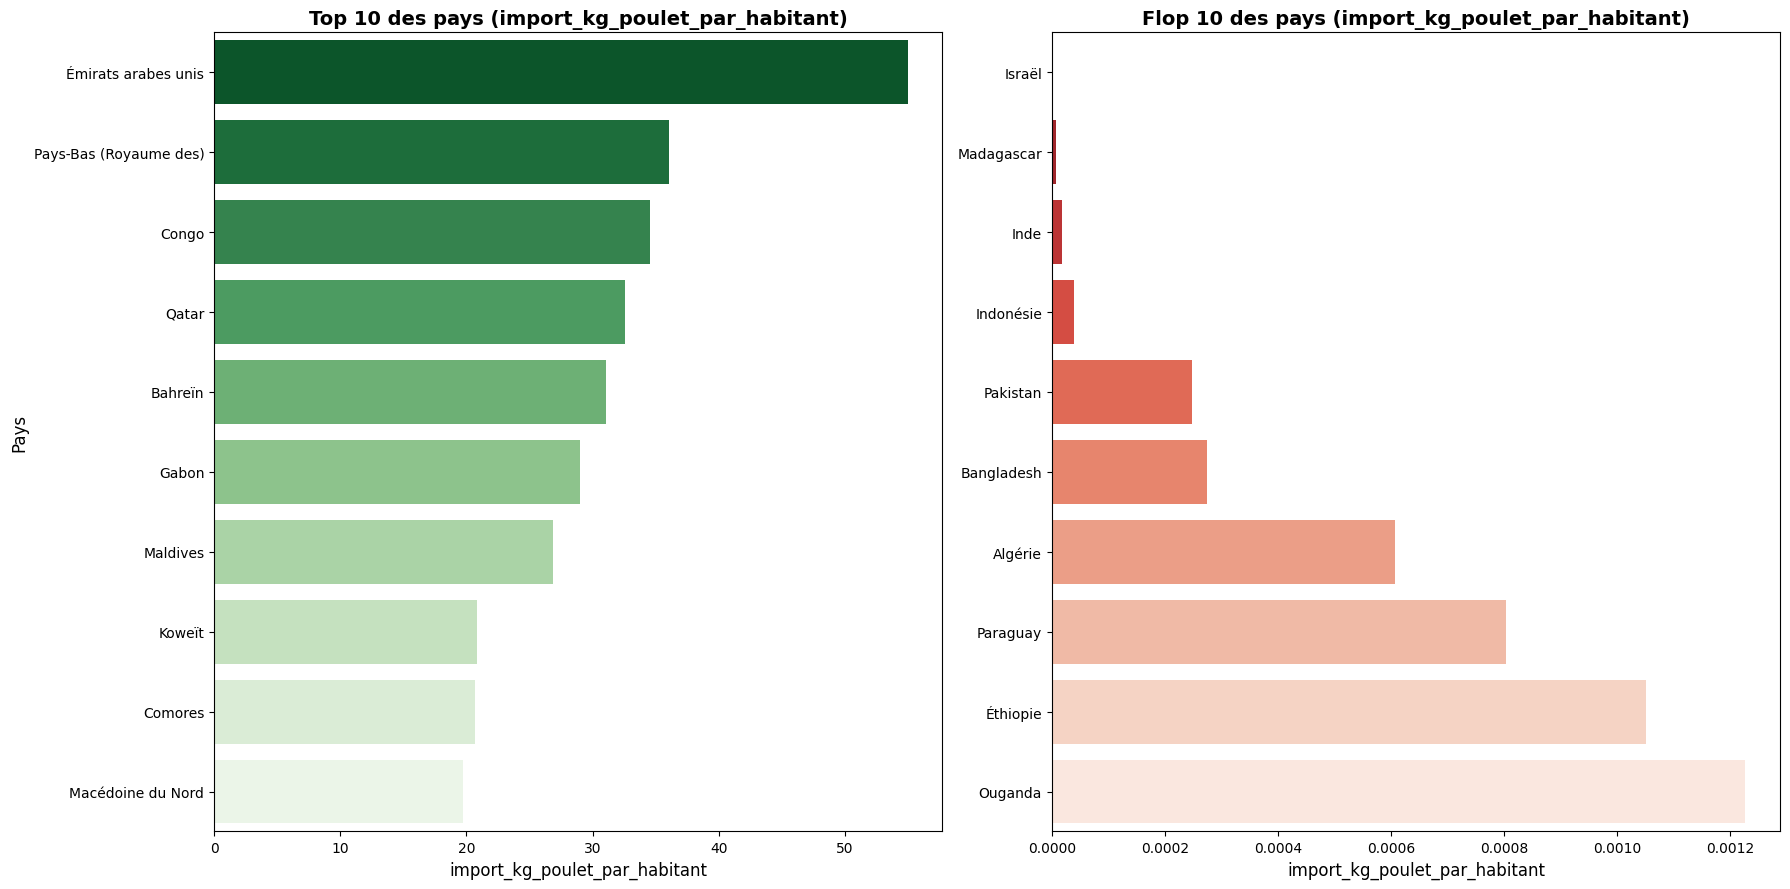

In [167]:
plot_top_flop_10(df_final, 'import_kg_poulet_par_habitant')

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\MonCompte\AppData\Local\Temp\ipykernel_25924\178320132.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


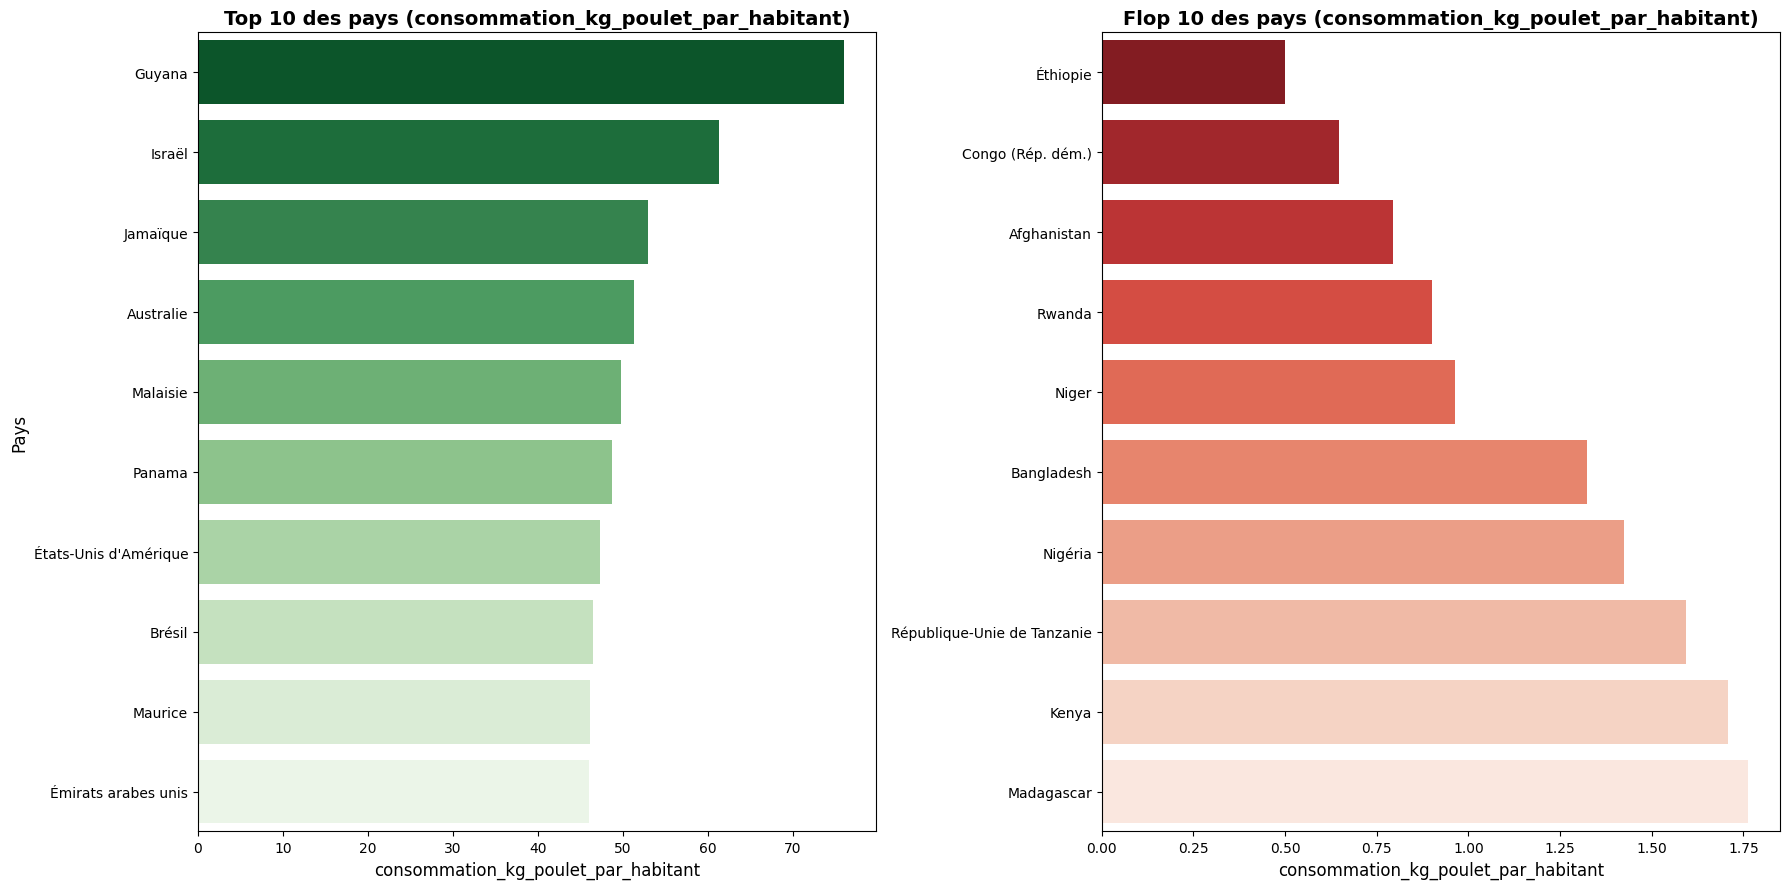

In [168]:
plot_top_flop_10(df_final, 'consommation_kg_poulet_par_habitant')

Text(0, 0.5, 'PIB_par_habitants')

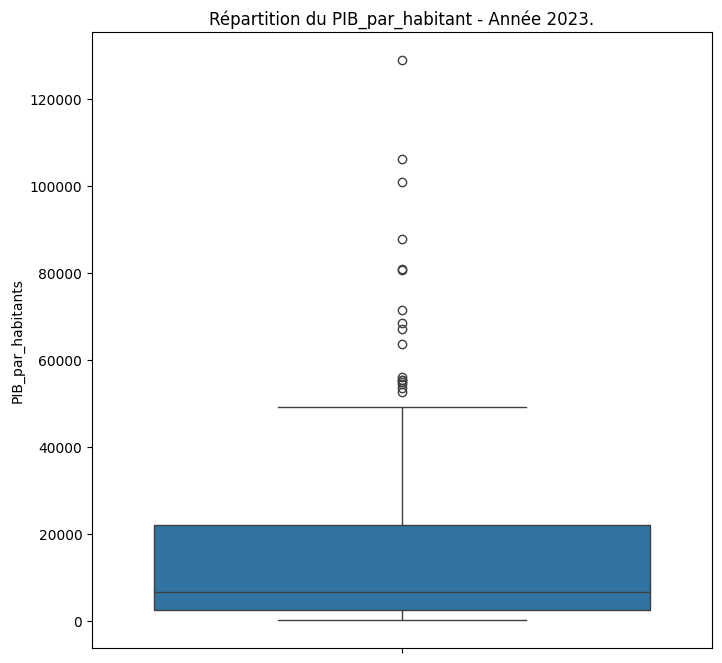

In [169]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='PIB_par_habitant', data=df_final)
plt.title("Répartition du PIB_par_habitant - Année 2023.")
plt.ylabel("PIB_par_habitants")

Text(0, 0.5, "'%' d'accés")

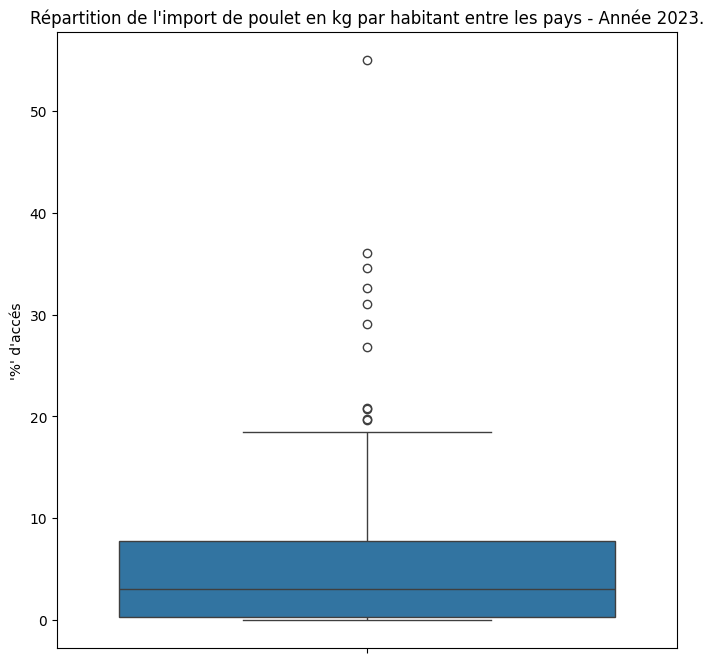

In [170]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='import_kg_poulet_par_habitant', data=df_final)
plt.title("Répartition de l'import de poulet en kg par habitant entre les pays - Année 2023.")
plt.ylabel("'%' d'accés")

Text(0, 0.5, "'%' d'accés")

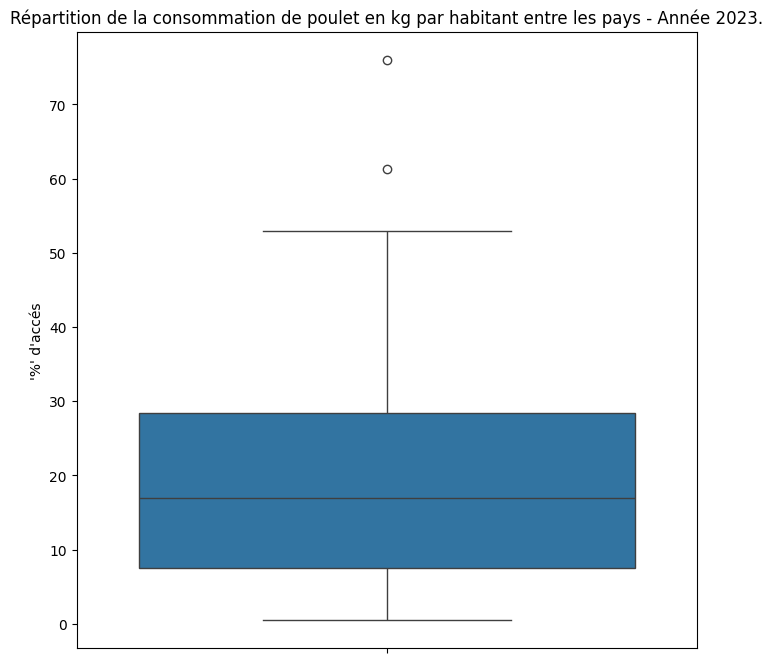

In [171]:
plt.figure(figsize=(8, 8))
sns.boxplot(y='consommation_kg_poulet_par_habitant', data=df_final)
plt.title("Répartition de la consommation de poulet en kg par habitant entre les pays - Année 2023.")
plt.ylabel("'%' d'accés")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Extraction du fichier au format csv</h2>
</div>

In [172]:
df_final.to_csv('df_final_2023.csv', index=False)